In [1]:
from astroquery.gaia import Gaia
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from astropy.timeseries import LombScargle
import astropy.units as u

In [2]:
Gaia.login()

INFO: Login to gaia TAP server [astroquery.gaia.core]


User:  jsanch02
Password:  ········


INFO: OK [astroquery.utils.tap.core]
INFO: Login to gaia data server [astroquery.gaia.core]
INFO: OK [astroquery.utils.tap.core]


In [3]:
# ============= USER OPTIONS =============
query = """
SELECT  TOP 100 

gaia.source_id, phot_variable_flag, sosrrl.pf, sosrrl.epoch_g

FROM gaiadr3.gaia_source AS gaia

LEFT OUTER JOIN gaiadr3.vari_rrlyrae AS sosrrl USING (source_id)

where num_clean_epochs_g > 40

AND sosrrl.pf IS NOT NULL
     
"""

        
cache_file = "test.csv"
overwrite_cache = False
# ========================================

if os.path.exists(cache_file) and not overwrite_cache:
    print(f"Loading cached results from {cache_file}")
    df = pd.read_csv(cache_file)
else:
    print("Querying Gaia archive (this may take a while)...")
    job = Gaia.launch_job_async(query)
    results = job.get_results().to_pandas()
    results.to_csv(cache_file, index=False)
    print(f"Results cached to {cache_file}")

Loading cached results from test.csv


In [4]:
results = df
print(results[:])

              source_id phot_variable_flag        pf      epoch_g
0    245002531050576896           VARIABLE  0.520512  1705.132336
1    245504251951140864           VARIABLE  0.507115  1705.941237
2    245823861938360064           VARIABLE  0.478764  1705.224346
3    246756973652292992           VARIABLE  0.489303  1705.694932
4    359112665277840512           VARIABLE  0.501780  1700.672707
..                  ...                ...       ...          ...
95  2195958504330260224           VARIABLE  0.495418  1687.147981
96  2195979635570512640           VARIABLE  0.527883  1688.650673
97  2196012968813801984           VARIABLE  0.605841  1687.237710
98  2196067703877567232           VARIABLE  0.575690  1689.219273
99  2196103884681824384           VARIABLE  0.528914  1688.820948

[100 rows x 4 columns]


In [5]:
retrieval_type = 'EPOCH_PHOTOMETRY'    # Options are: 'EPOCH_PHOTOMETRY', 'MCMC_GSPPHOT', 'MCMC_MSC', 'XP_SAMPLED', 'XP_CONTINUOUS', 'RVS' 
data_structure = 'INDIVIDUAL' # Options are: 'INDIVIDUAL' and 'RAW'.
data_release   = 'Gaia DR3'   # Options are: 'Gaia DR3' (default), 'Gaia DR2'

ids = results['source_id']

datalink_all   = []

for i in range(len(ids)):
   i = i + 1
   print(f'Downloading Chunk #{i}; N_files = {len(ids)}')
   datalink  = Gaia.load_data(ids=ids, data_release = data_release, retrieval_type=retrieval_type, format = 'votable', data_structure = data_structure, dump_to_file=True)
   datalink_all.append(datalink)       

INFO: DataLink products will be stored in the /Users/jsanchez/Downloads/AY128/course_materials_fa2025/labs/datalink_output_20251014T205458.234442.zip file [astroquery.gaia.core]
INFO: DataLink products will be stored in the /Users/jsanchez/Downloads/AY128/course_materials_fa2025/labs/datalink_output_20251014T205502.395397.zip file [astroquery.gaia.core]
INFO: DataLink products will be stored in the /Users/jsanchez/Downloads/AY128/course_materials_fa2025/labs/datalink_output_20251014T205504.665628.zip file [astroquery.gaia.core]
INFO: DataLink products will be stored in the /Users/jsanchez/Downloads/AY128/course_materials_fa2025/labs/datalink_output_20251014T205507.013074.zip file [astroquery.gaia.core]
INFO: DataLink products will be stored in the /Users/jsanchez/Downloads/AY128/course_materials_fa2025/labs/datalink_output_20251014T205509.122933.zip file [astroquery.gaia.core]
INFO: DataLink products will be stored in the /Users/jsanchez/Downloads/AY128/course_materials_fa2025/labs/dat

SSLEOFError: [SSL: UNEXPECTED_EOF_WHILE_READING] EOF occurred in violation of protocol (_ssl.c:1000)

In [6]:
datalink_out = datalink_all[0]

for inp_dict in datalink_all[1:]:
   datalink_out.update(inp_dict)

keys = list(datalink_out.keys())
print(f'* The merged dictionary contains {len(keys)} elements')    

* The merged dictionary contains 100 elements


In [7]:
print(list(datalink_out.keys())[:20])

['EPOCH_PHOTOMETRY-Gaia DR3 359112665277840512.xml', 'EPOCH_PHOTOMETRY-Gaia DR3 5902512467598855040.xml', 'EPOCH_PHOTOMETRY-Gaia DR3 6061866508861866240.xml', 'EPOCH_PHOTOMETRY-Gaia DR3 414254032403091072.xml', 'EPOCH_PHOTOMETRY-Gaia DR3 5712768539085118080.xml', 'EPOCH_PHOTOMETRY-Gaia DR3 6061675365655690624.xml', 'EPOCH_PHOTOMETRY-Gaia DR3 415808810565481856.xml', 'EPOCH_PHOTOMETRY-Gaia DR3 5712783421155718144.xml', 'EPOCH_PHOTOMETRY-Gaia DR3 1933740099389964544.xml', 'EPOCH_PHOTOMETRY-Gaia DR3 1934591533705740928.xml', 'EPOCH_PHOTOMETRY-Gaia DR3 5712952471067022208.xml', 'EPOCH_PHOTOMETRY-Gaia DR3 246756973652292992.xml', 'EPOCH_PHOTOMETRY-Gaia DR3 1935230693559394816.xml', 'EPOCH_PHOTOMETRY-Gaia DR3 2195648132814029312.xml', 'EPOCH_PHOTOMETRY-Gaia DR3 5902375922011339008.xml', 'EPOCH_PHOTOMETRY-Gaia DR3 1934025701833533056.xml', 'EPOCH_PHOTOMETRY-Gaia DR3 5712433192340393984.xml', 'EPOCH_PHOTOMETRY-Gaia DR3 1935104150941800320.xml', 'EPOCH_PHOTOMETRY-Gaia DR3 4317959119274420096.xm

In [8]:
source_id = 245002531050576896
for key in datalink_out.keys():
    if str(source_id) in key:
        print("Match found:", key)
   

Match found: EPOCH_PHOTOMETRY-Gaia DR3 245002531050576896.xml


In [9]:
matching_key = None
for key in datalink_out.keys():
    if str(source_id) in key:
        matching_key = key
        break

if matching_key:
    votable = datalink_out[matching_key][0]
    votable_data = votable.to_table()
    print(votable_data[:5])  # first 5 rows
else:
    print("Source ID not found in datalink_out")


    transit_id      g_transit_time   ... rp_other_flags rejected_by_photometry
                          d          ...                                      
----------------- ------------------ ... -------------- ----------------------
17127455701357856 1706.5856067422114 ...              0                  False
18963346597122114 1739.7894840400877 ...       16779264                  False
18973087399306294 1739.9656540065293 ...              0                  False
24162597315961460  1833.815905206406 ...              0                  False
24166689644275234    1833.8899083171 ...              0                  False


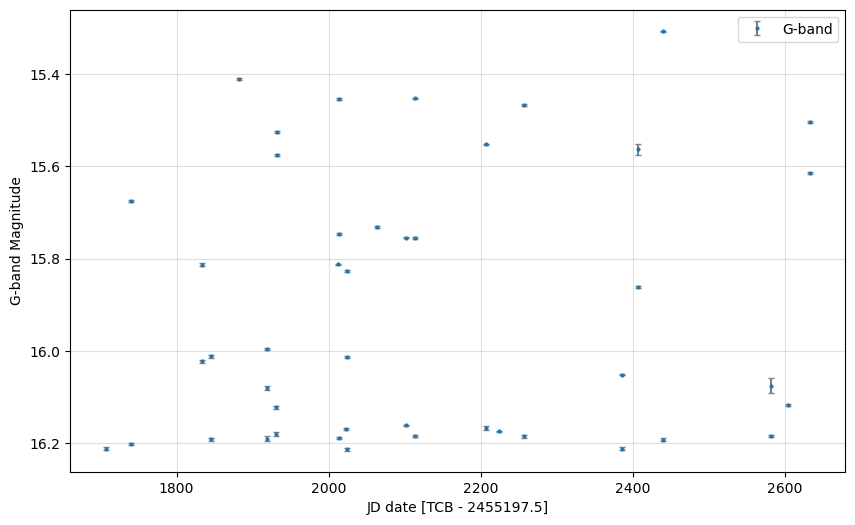

In [19]:
time = votable_data["g_transit_time"]
mag = votable_data["g_transit_mag"]
flux = votable_data['g_transit_flux']
flux_error = votable_data['g_transit_flux_error']

mag_error = (2.5 / np.log(10)) * (flux_error / flux)

plt.figure(figsize=(10, 6))
plt.errorbar(time, mag, yerr=mag_error, fmt='o', markersize=2, ecolor='gray', capsize=2, label='G-band')


plt.gca().invert_yaxis()

plt.xlabel("JD date [TCB - 2455197.5]")
plt.ylabel("G-band Magnitude")
# plt.title(f"RR Lyrae Light Curve (G-band) for {source_id}")
plt.legend()
plt.grid(alpha=0.4)
plt.savefig('light curve with mag uncertainties.jpeg')
plt.show()

Estimated period: 0.5205 d (days)


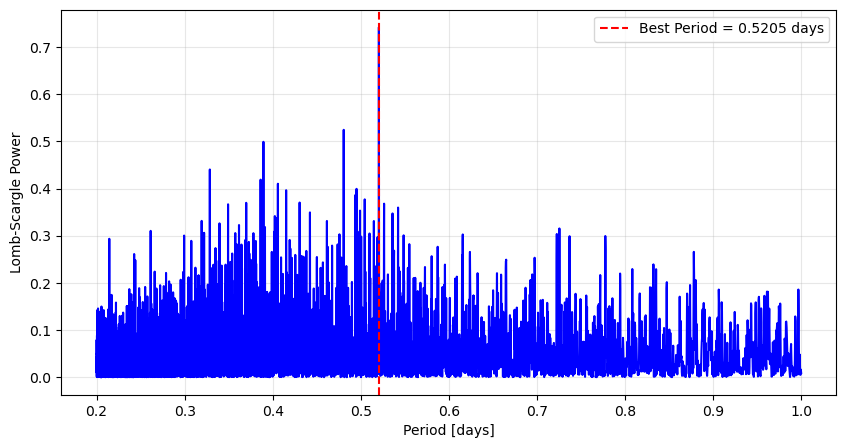

In [22]:
time = votable_data["g_transit_time"]
mag = votable_data["g_transit_mag"]

# Frequency range: 1/Period
min_period = 0.2 * u.day
max_period = 1.0 * u.day 
frequency = np.linspace(1/max_period, 1/min_period, 10000) 

# Compute Lomb-Scargle periodogram
ls = LombScargle(time, mag)
power = ls.power(frequency)

# Find the frequency with the highest power
best_frequency = frequency[np.argmax(power)]
best_period = 1 / best_frequency

print(f"Estimated period: {best_period:.4f} (days)")

periods = (1 / frequency).value  
power = power  
best_period_val = best_period.value  

plt.figure(figsize=(10, 5))
plt.plot(periods, power, color='blue')
plt.axvline(best_period_val, color='red', linestyle='--', label=f'Best Period = {best_period_val:.4f} days')
plt.xlabel("Period [days]")
plt.ylabel("Lomb-Scargle Power")
# plt.title(f"Lomb-Scargle Periodogram for {source_id}")
plt.legend()
plt.grid(alpha=0.3)
plt.savefig('L-S plot example.jpeg')
plt.show()

In [12]:
# target_id = 245002531050576896
# i=0
# source_ids = results['source_id']

# for key in source_ids:
#     if key == target_id:
#         print("Found target id in row:",i)
#     else:
#         i+=1
    

### Average in Flux Space

The average flux is given by:

$$
\langle F \rangle = \frac{1}{N} \sum_{i=1}^{N} F_i
$$

---

### Convert Back to Magnitude

To convert the average flux back to magnitude:

$$
m = -2.5 \log_{10}(\langle F \rangle) + \text{ZP}
$$

where **ZP** (zero point) for the **Gaia G-band** is approximately:

$$
\text{ZP} \approx 25.6884
$$


In [24]:
ZP = 25.6873668671  # Gaia G-band zero point

flux = votable_data["g_transit_flux"]
flux_err = votable_data["g_transit_flux_error"]

# Weighted mean flux using flux errors
weights = 1 / (flux_err ** 2)
mean_flux = np.sum(weights * flux) / np.sum(weights)

# Convert mean flux to magnitude
mean_mag = -2.5 * np.log10(mean_flux) + ZP
print(f"Mean G-band magnitude: {mean_mag:.4f}")


Mean G-band magnitude: 15.9539


### Magnitude Uncertainty from Flux and Zero-Point Errors

The uncertainty on the **mean magnitude** combines both **flux errors** and **zero-point errors**.

---

#### Flux Error Propagation

The error in magnitude from the flux uncertainty is:

$$
\sigma_{m,\mathrm{flux}} = \frac{2.5}{\ln(10)} \cdot \frac{\sigma_F}{F}
$$

where:

- $ F $ = mean flux  
- $ \sigma_F $ = standard deviation (or uncertainty) of the flux (can be weighted)

---

#### Zero-Point Error

Gaia’s G-band zero-point error is approximately:

$$
\sigma_{\mathrm{ZP}} \approx 0.002 \ \text{mag}
$$

---

#### Combine Errors in Quadrature

To get the total magnitude uncertainty, combine both sources of error:

$$
\sigma_m = \sqrt{ \sigma_{m,\mathrm{flux}}^2 + \sigma_{\mathrm{ZP}}^2 }
$$


In [19]:
sigma_F = np.sqrt(1 / np.sum(weights))  # Weighted standard error of flux
sigma_mag_flux = (2.5 / np.log(10)) * (sigma_F / mean_flux)

sigma_ZP = 0.0027553202  # Gaia zero point error
sigma_mag = np.sqrt(sigma_mag_flux**2 + sigma_ZP**2)

print(f"Mean G-band magnitude error: {sigma_mag:8f}")


Mean G-band magnitude error: 0.002773


In [28]:
def analyze_light_curve(df,source_id):
    
    time = df["g_transit_time"]
    mag = df["g_transit_mag"]
    flux = df["g_transit_flux"]
    flux_err = df["g_transit_flux_error"]

    
    # Frequency range: 1/Period
    min_period = 0.2 * u.day
    max_period = 1.0 * u.day 
    frequency = np.linspace(1/max_period, 1/min_period, 10000) 
    frequency = frequency.value

    # Compute Lomb-Scargle periodogram
    ls = LombScargle(time, mag)
    power = ls.power(frequency)

    # Find the frequency with the highest power
    best_frequency = frequency[np.argmax(power)]
    best_period = 1 / best_frequency


    # Convert to plain float arrays
    periods = (1 / frequency) # Convert Quantity (1/frequency) to unitless array
    power = power  # already unitless, probably
    best_period_val = best_period  # Best period in float days

    plt.figure(figsize=(10, 5))
    plt.plot(periods, power, color='blue')
    plt.axvline(best_period_val, color='red', linestyle='--', label=f'Best Period = {best_period_val:.4f} days')
    plt.xlabel("Period [days]")
    plt.ylabel("Lomb-Scargle Power")
    plt.title(f"Lomb-Scargle Periodogram for: {source_id}")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()


    
    # Mean G-band magnitude
    ZP = 25.6884
    weights = 1 / (flux_err ** 2)
    mean_flux = np.sum(weights * flux) / np.sum(weights)
    mean_mag = -2.5 * np.log10(mean_flux) + ZP
    
    # Error propagation
    sigma_F = np.sqrt(1 / np.sum(weights))
    sigma_mag_flux = (2.5 / np.log(10)) * (sigma_F / mean_flux)
    sigma_ZP = 0.002
    sigma_mag = np.sqrt(sigma_mag_flux**2 + sigma_ZP**2)

    return best_period, mean_mag, sigma_mag


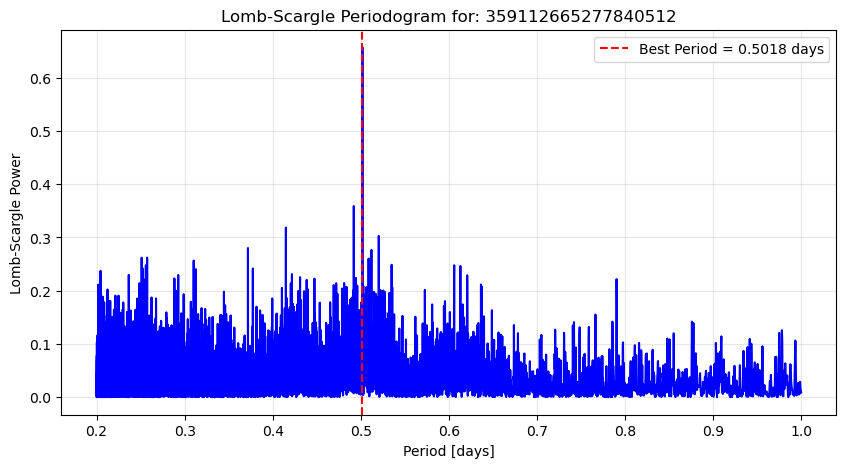

/opt/anaconda3/lib/python3.12/site-packages/astropy/timeseries/periodograms/lombscargle/implementations/utils.py:70: RuntimeWarning: invalid value encountered in cast
  ilo = np.clip((x - M // 2).astype(int), 0, N - M)


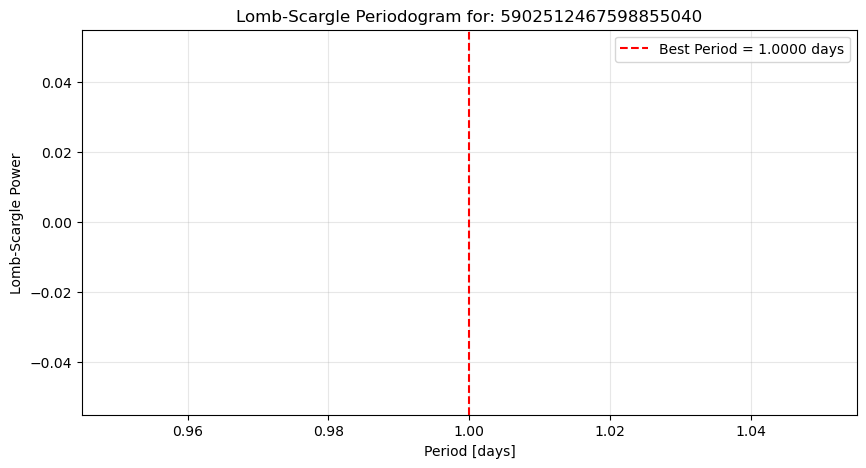

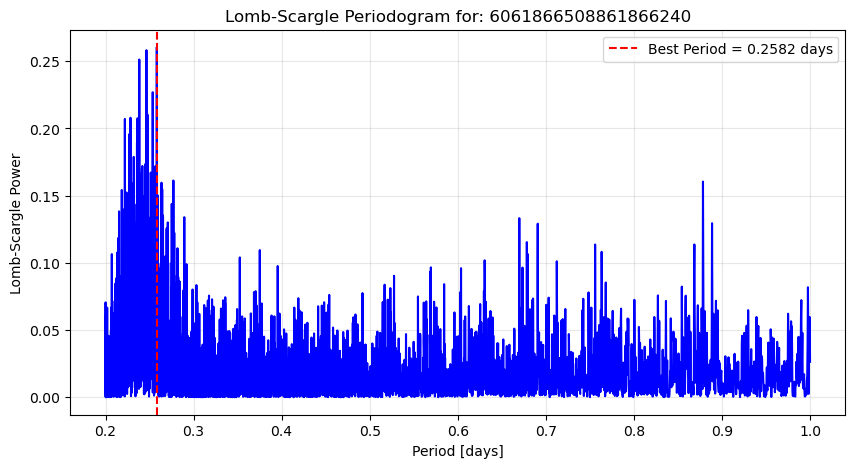

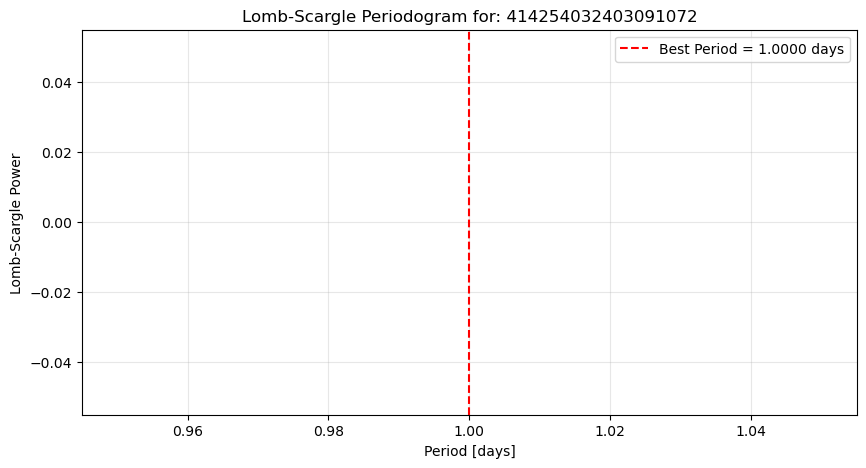

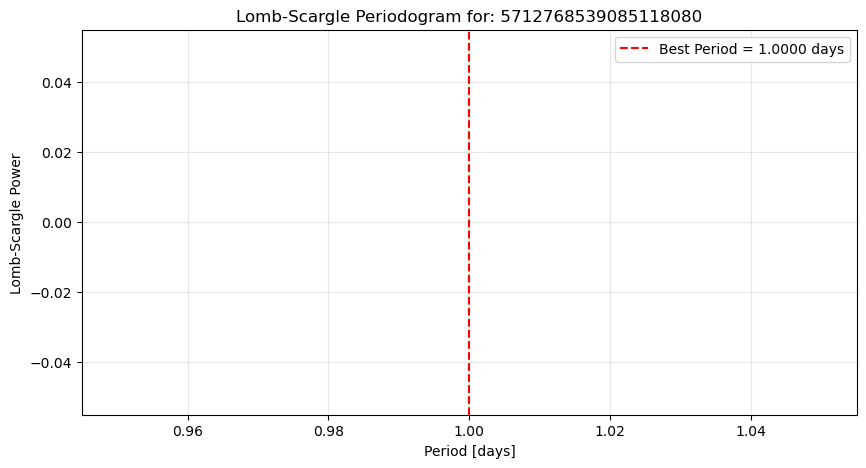

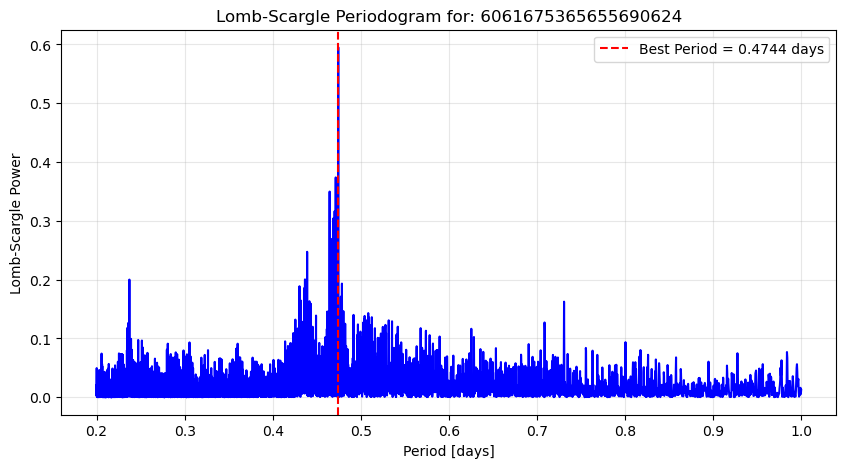

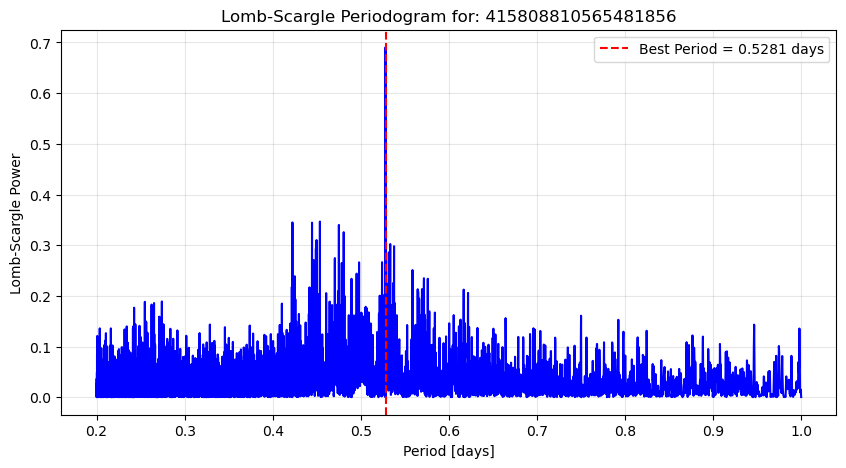

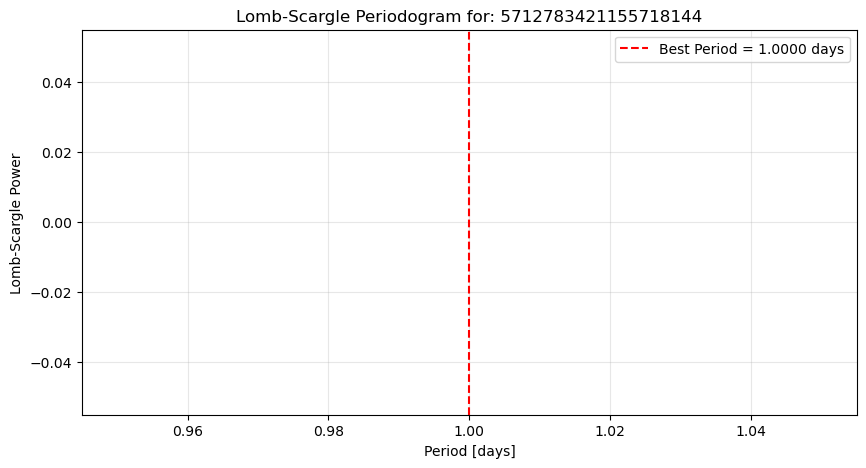

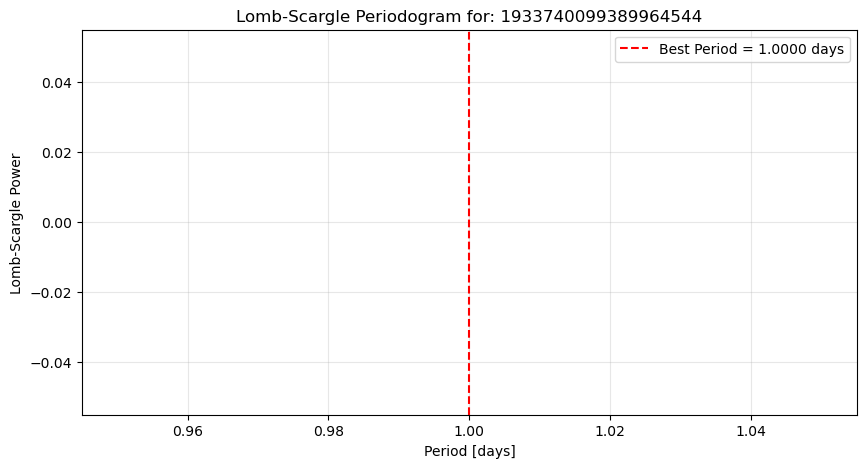

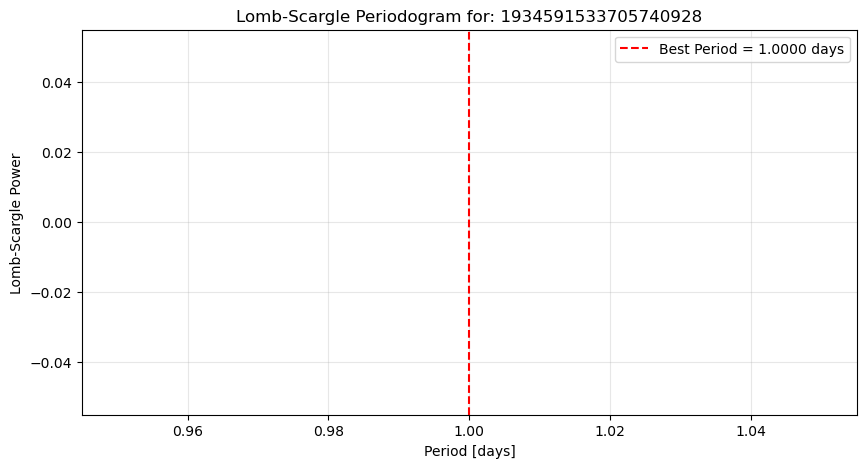

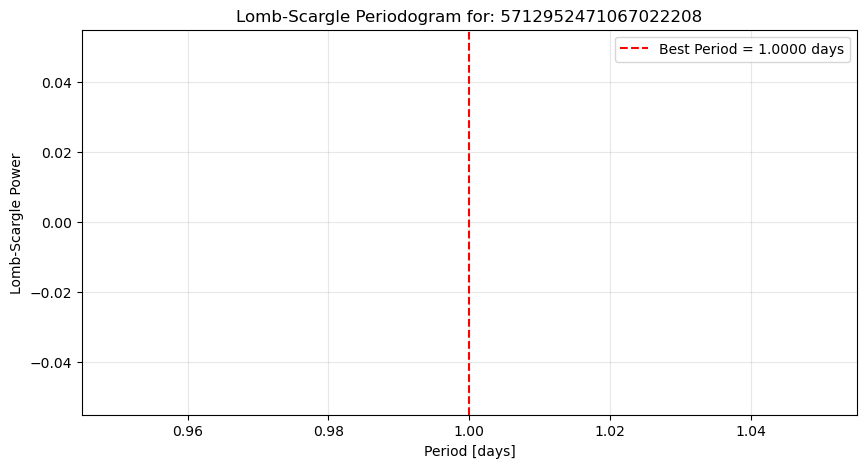

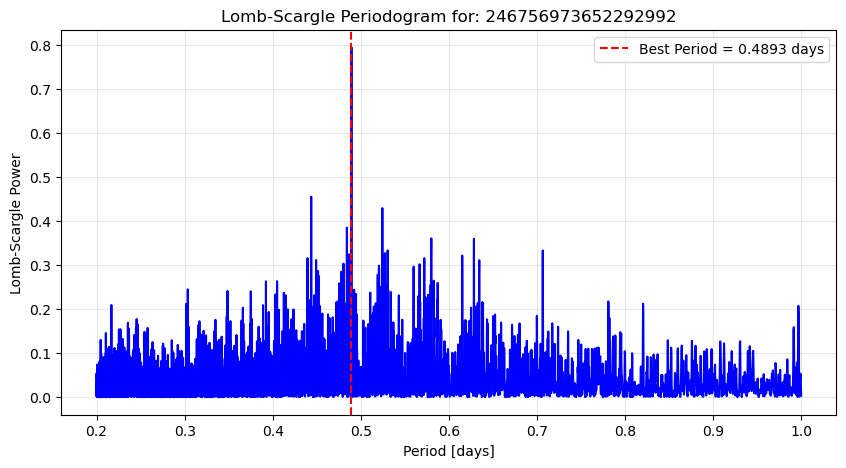

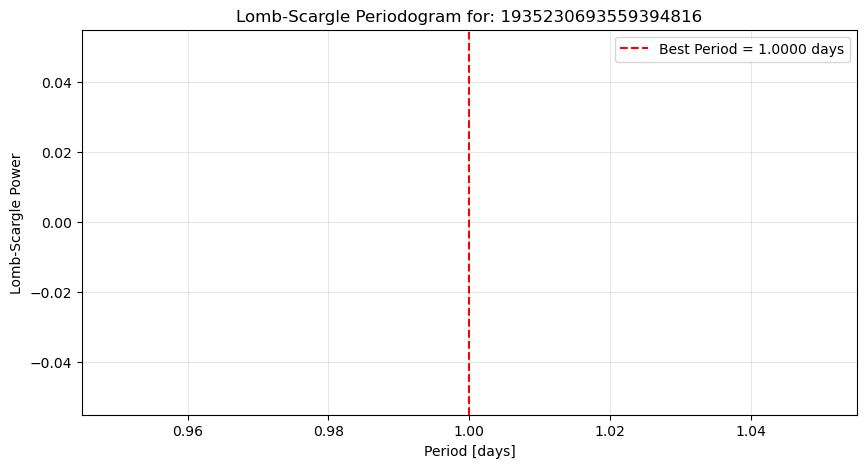

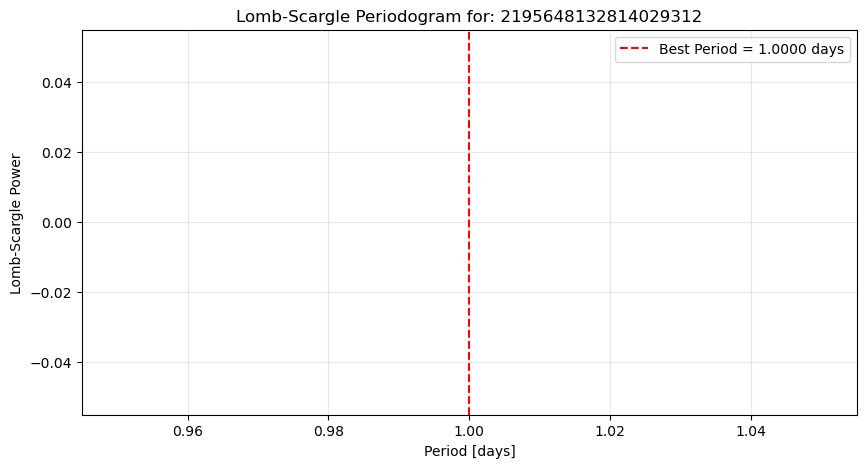

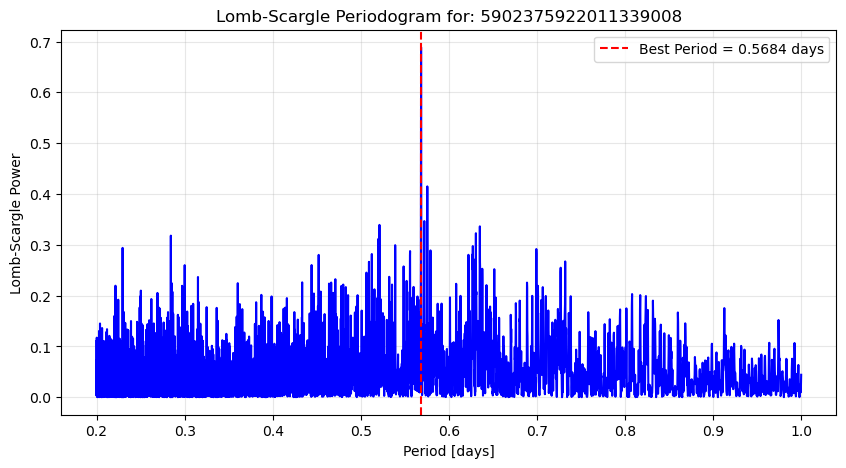

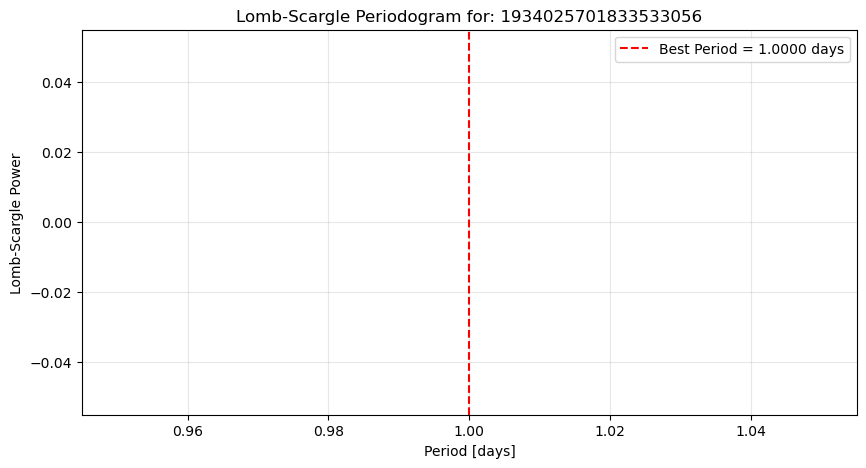

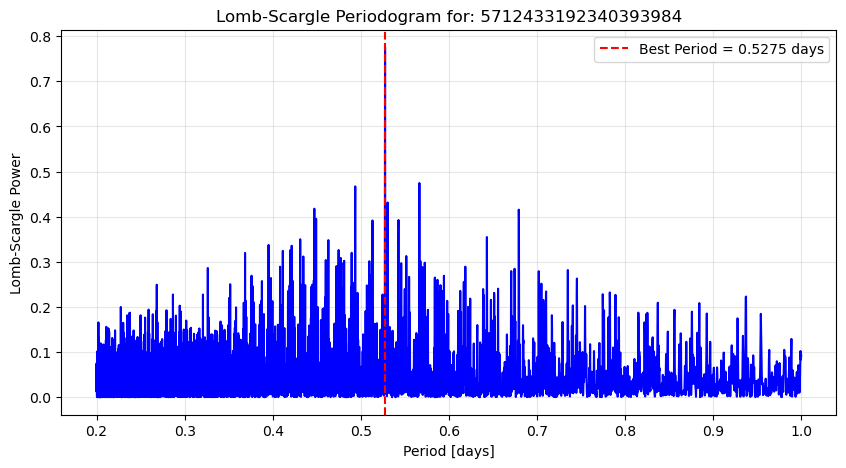

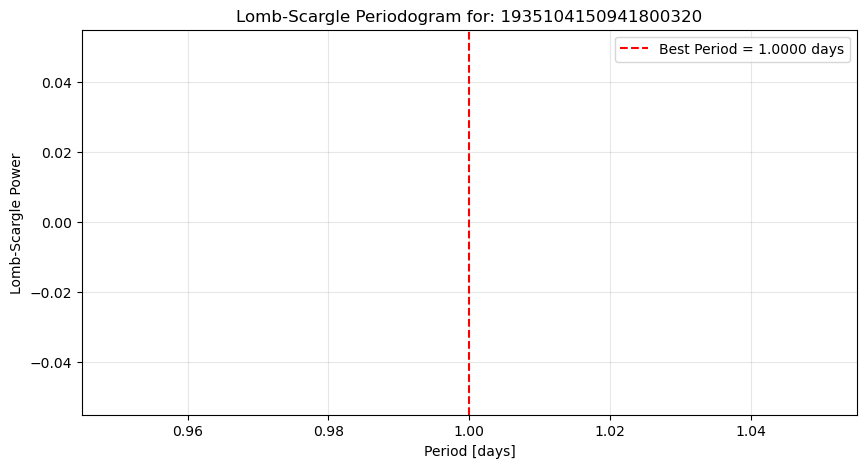

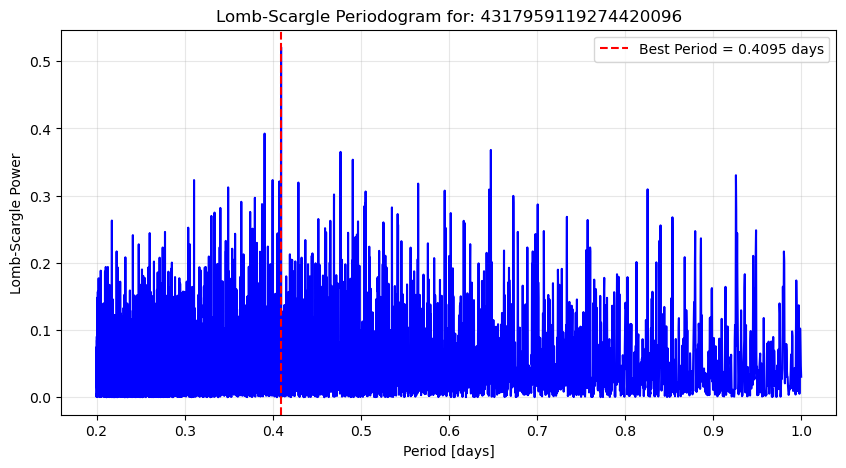

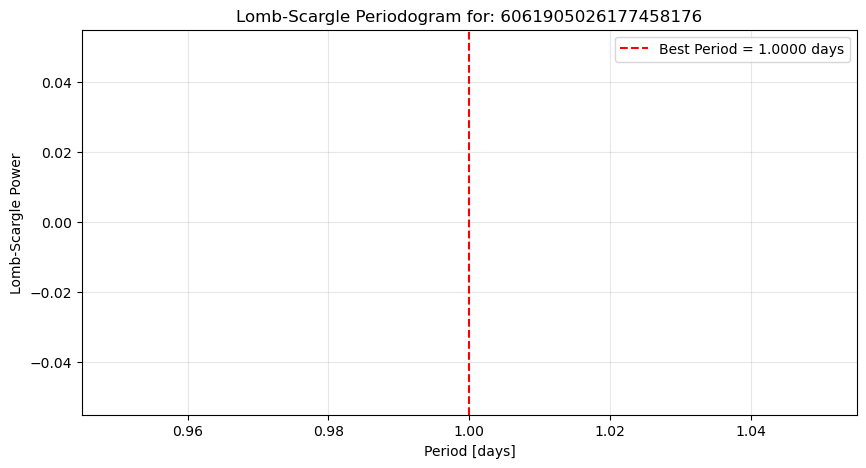

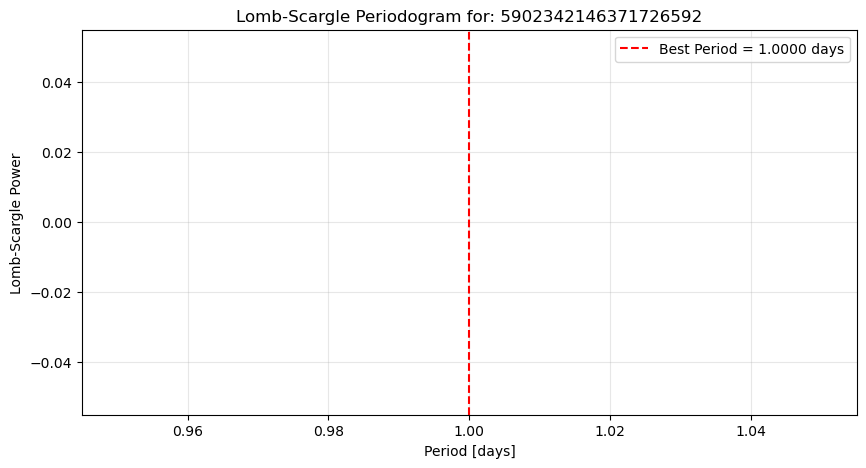

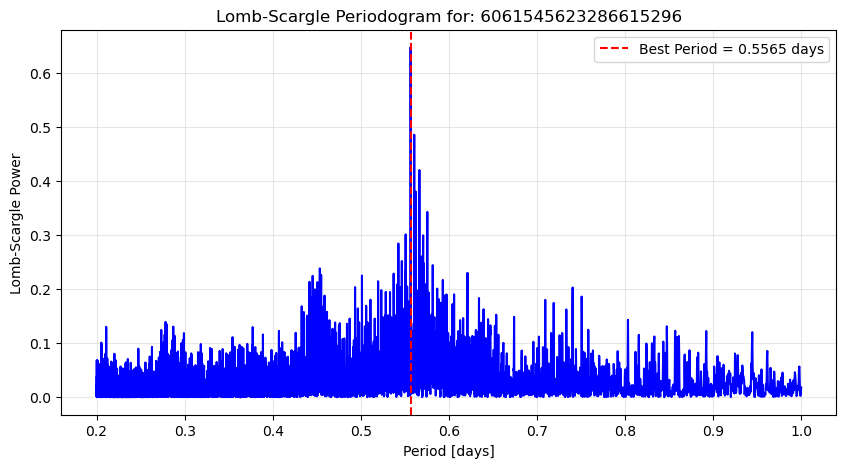

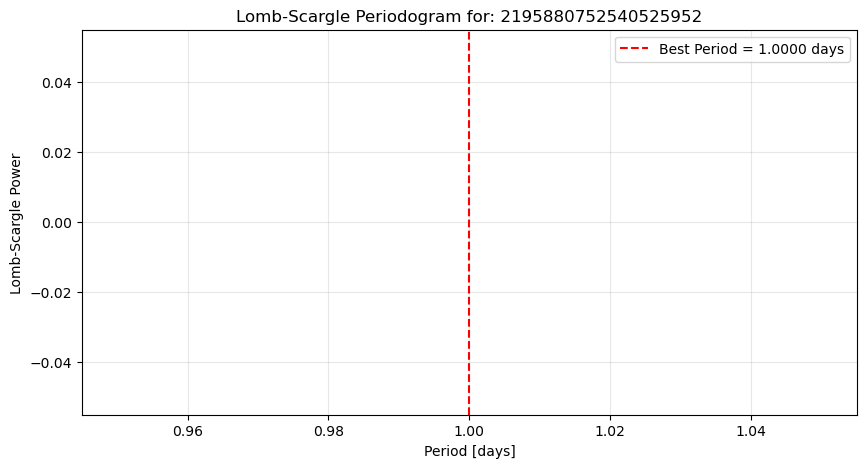

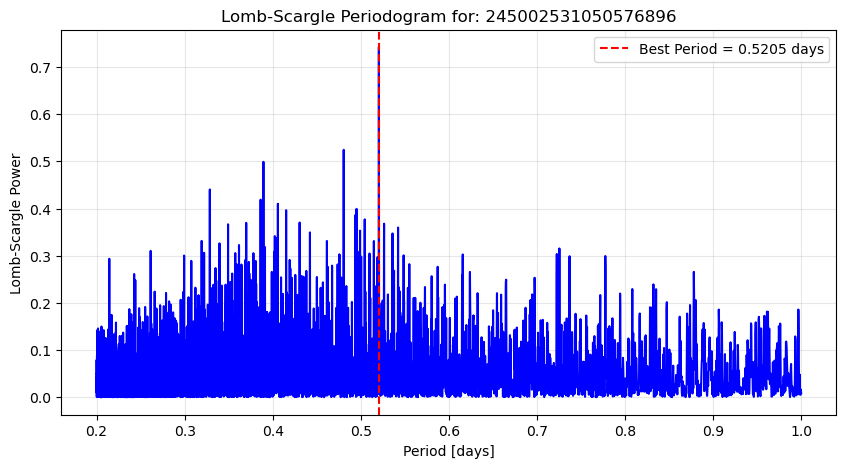

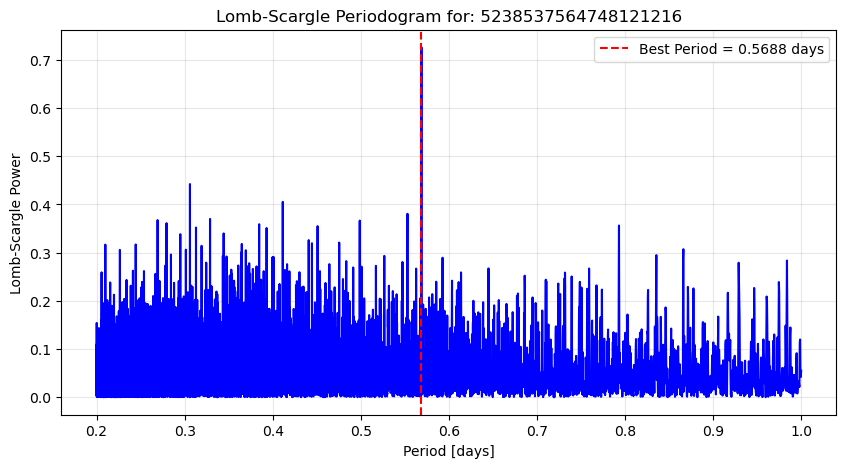

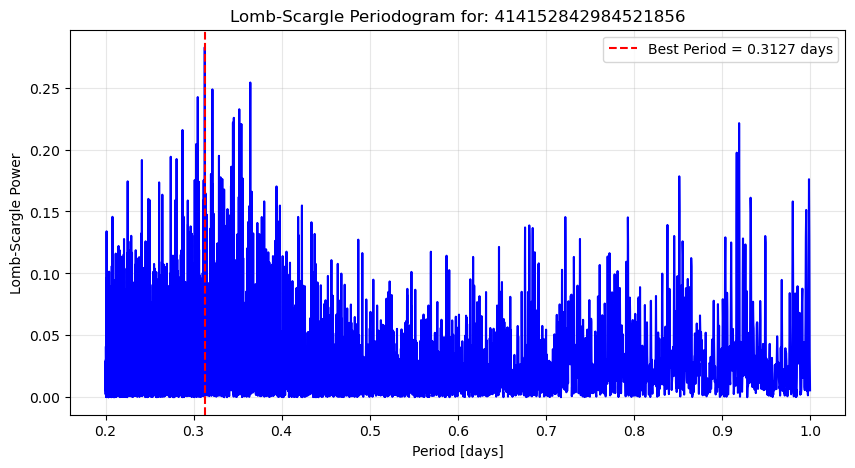

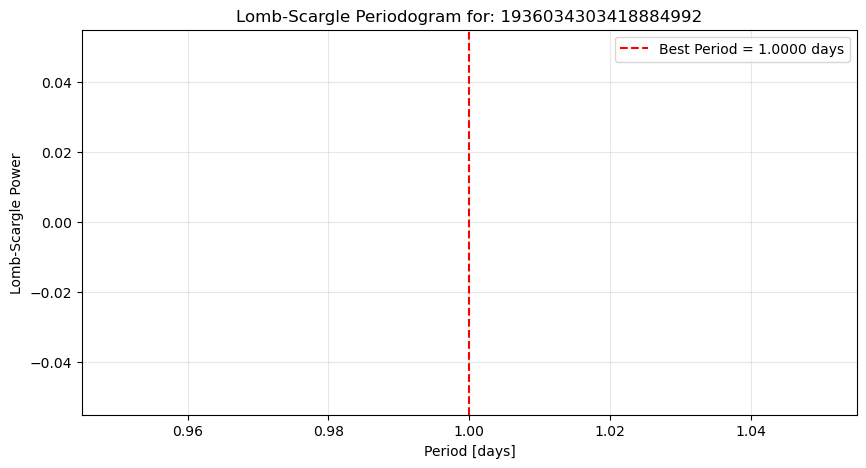

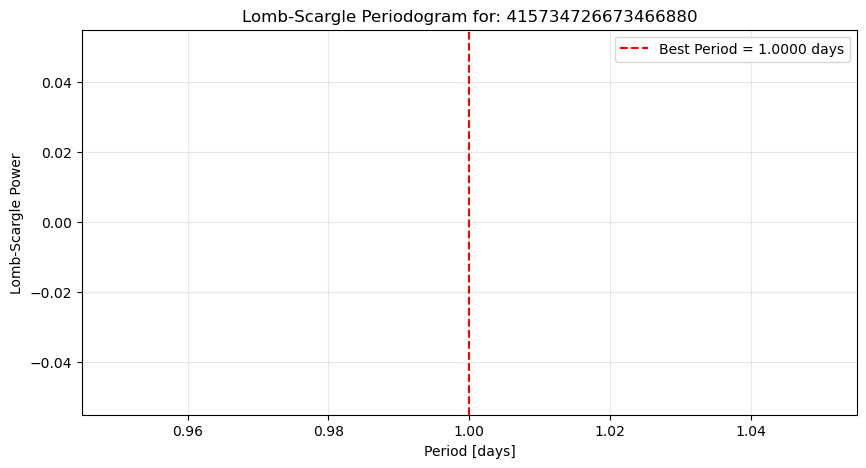

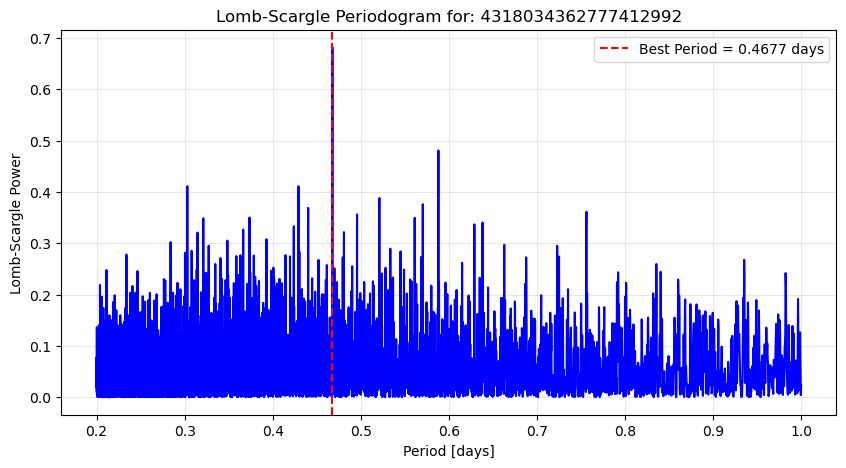

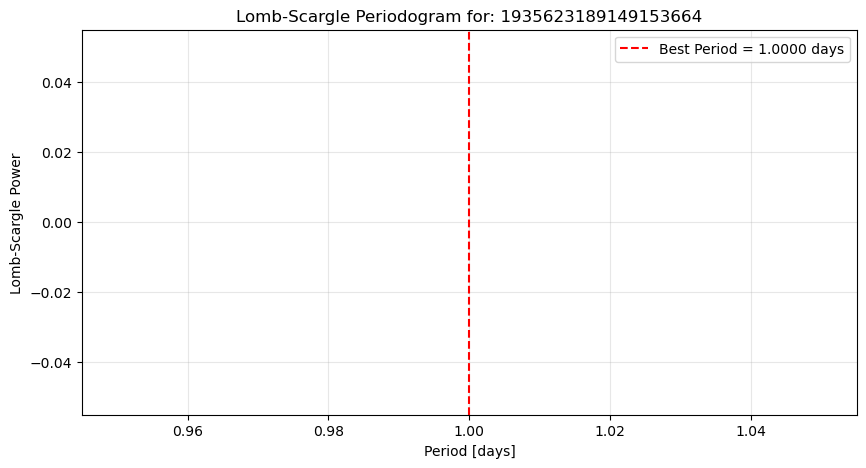

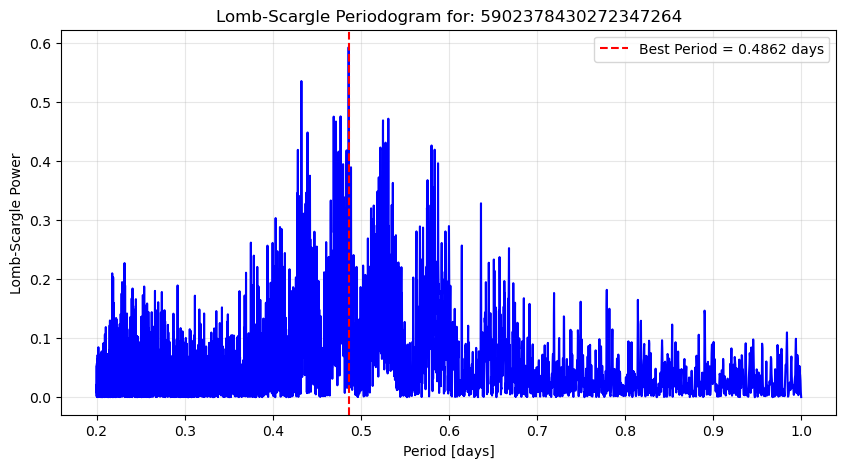

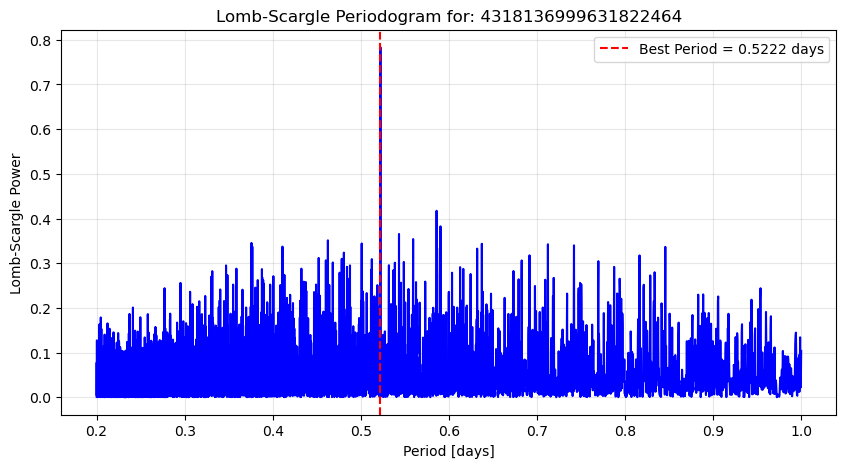

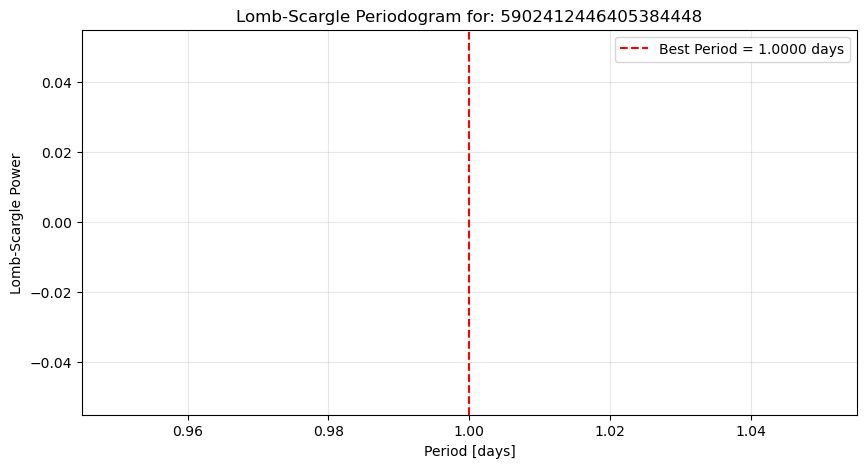

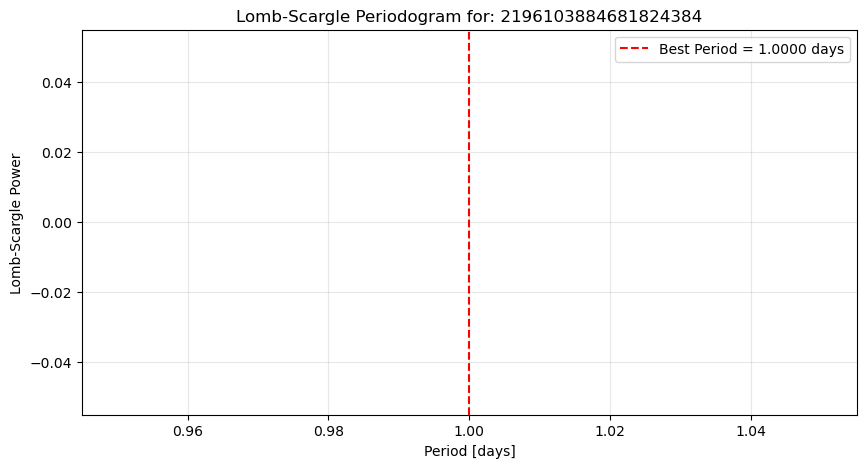

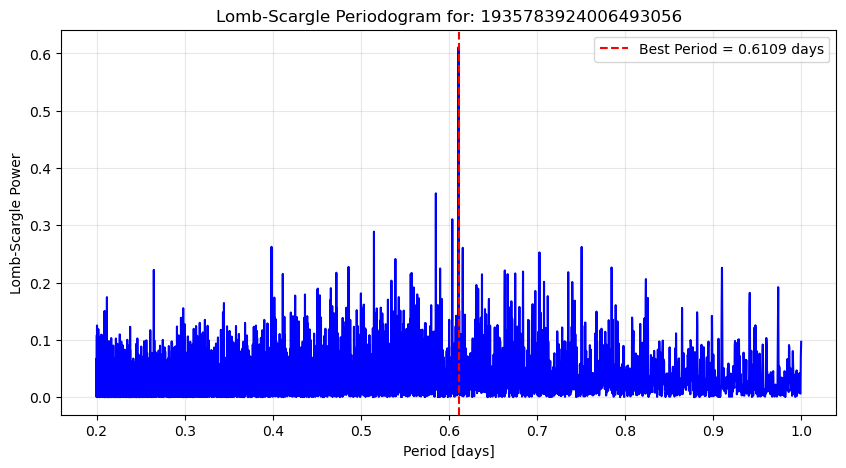

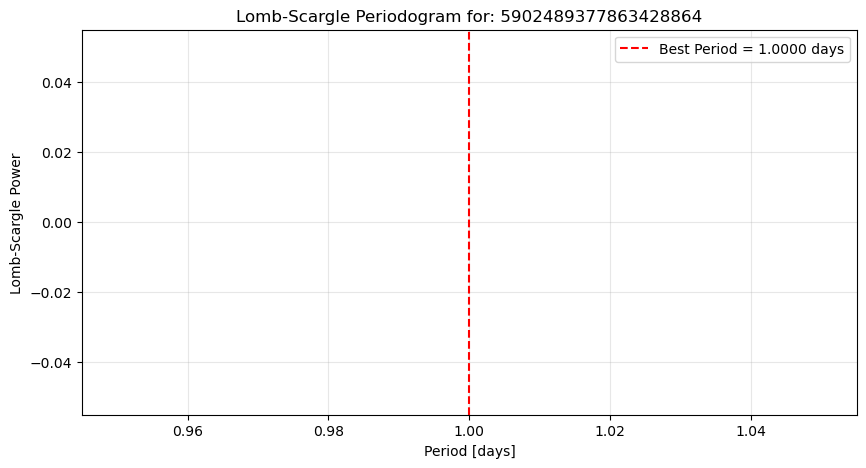

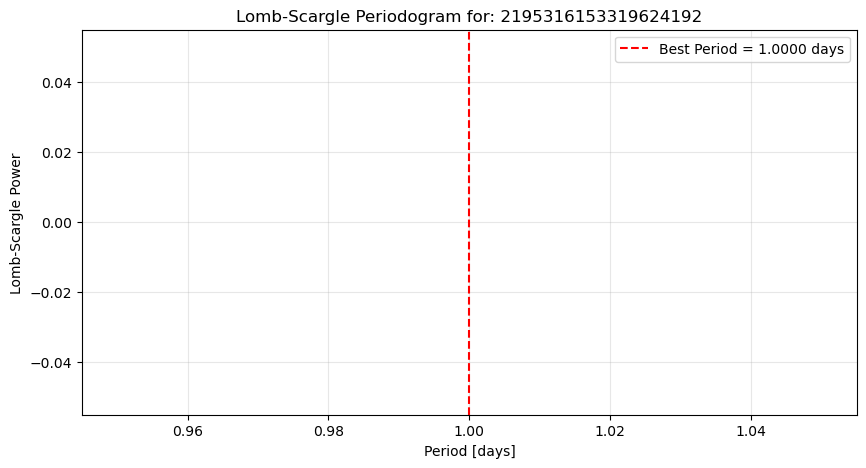

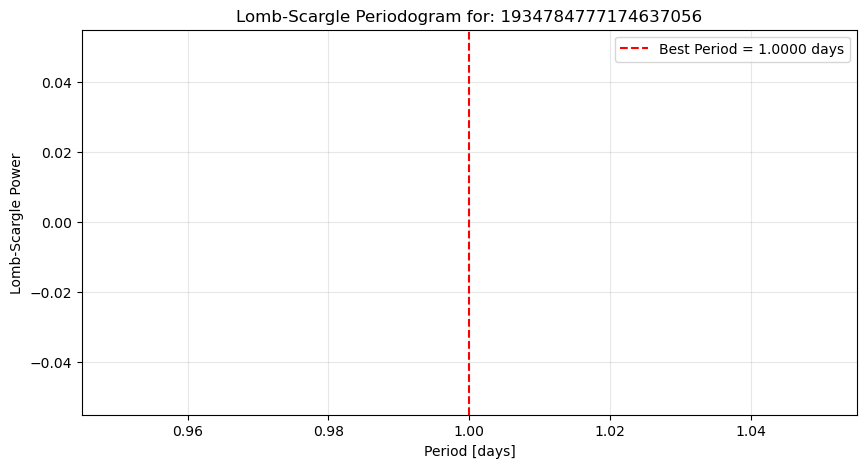

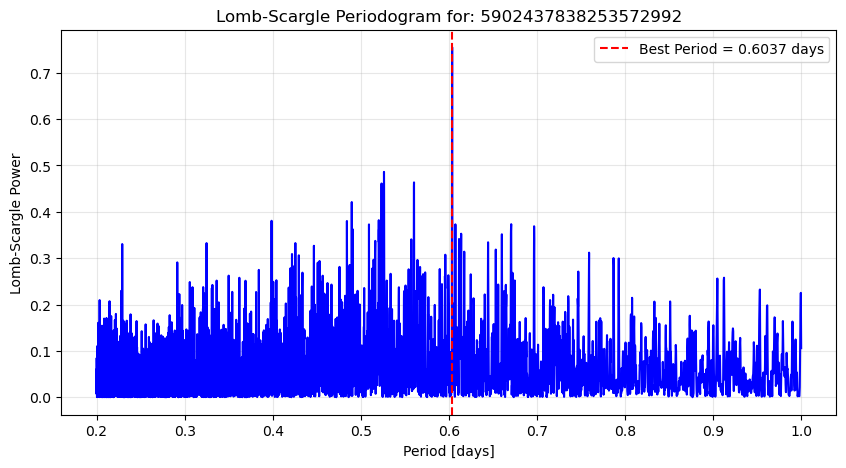

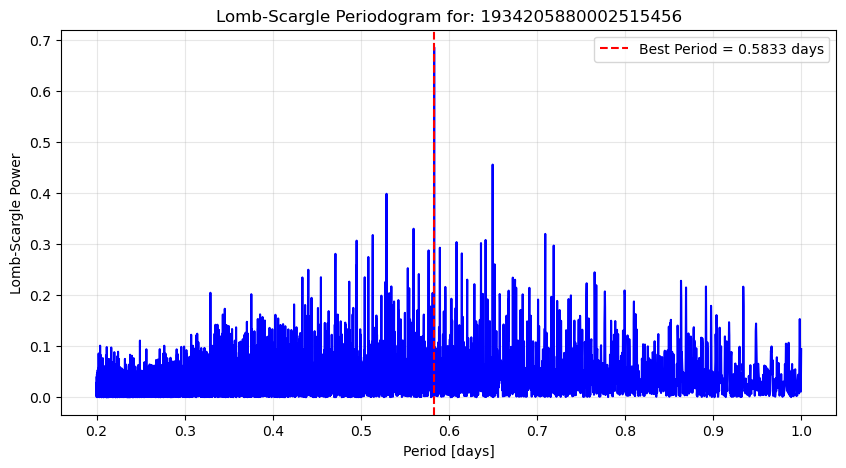

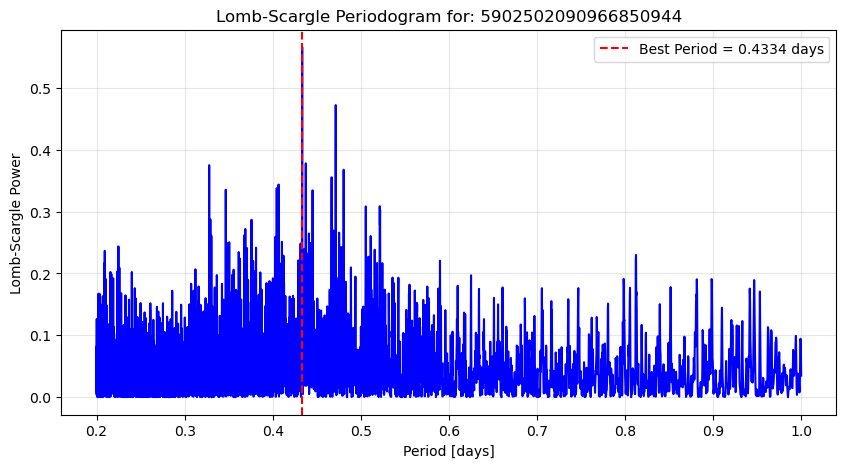

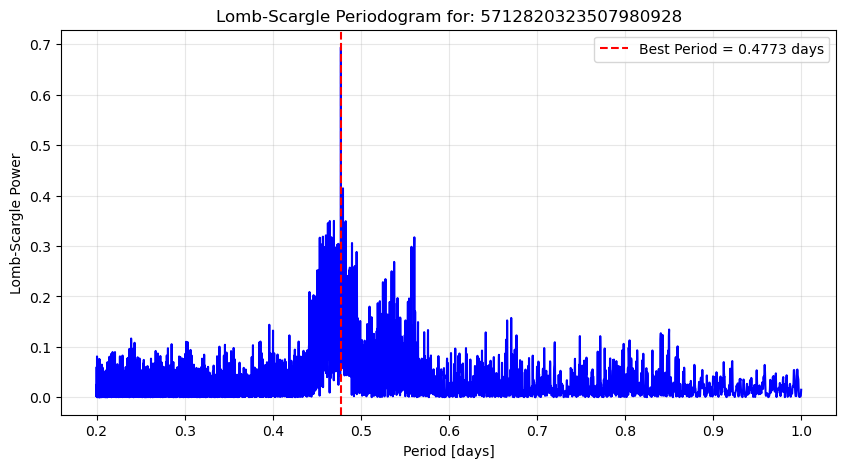

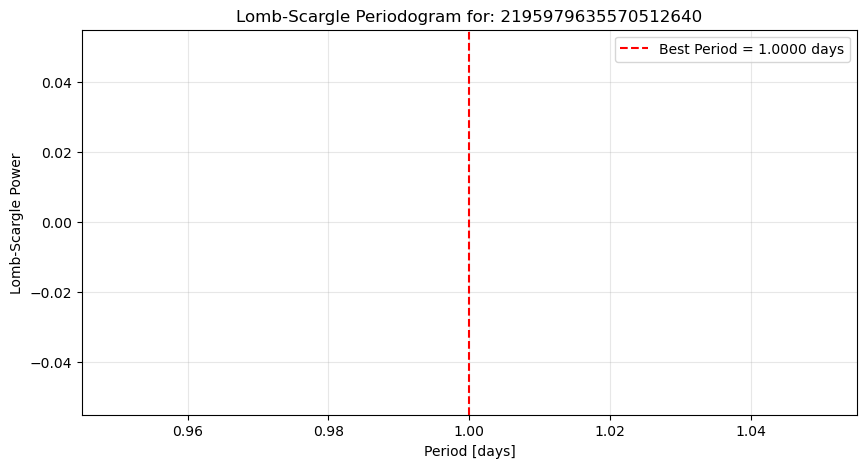

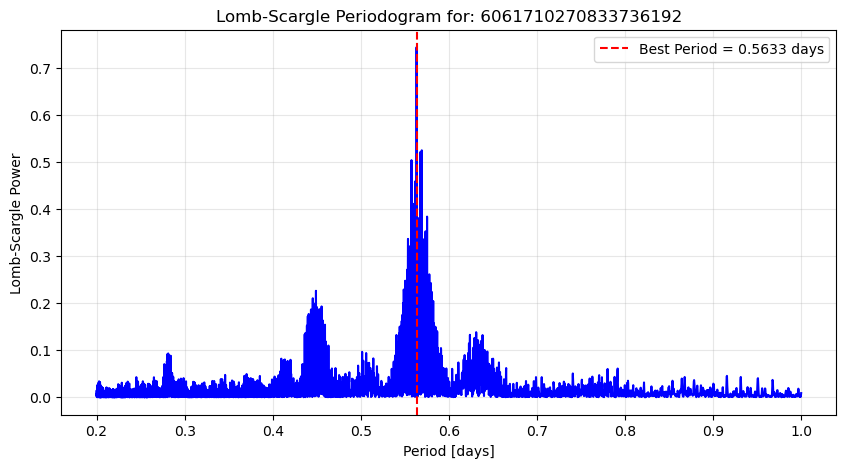

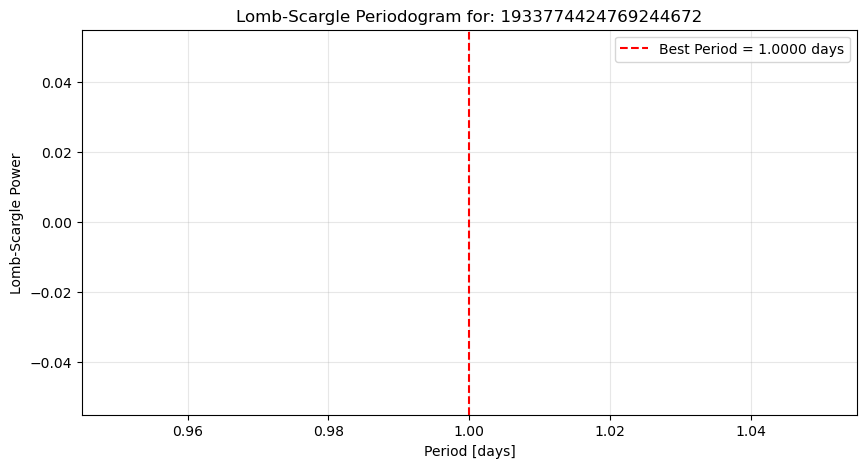

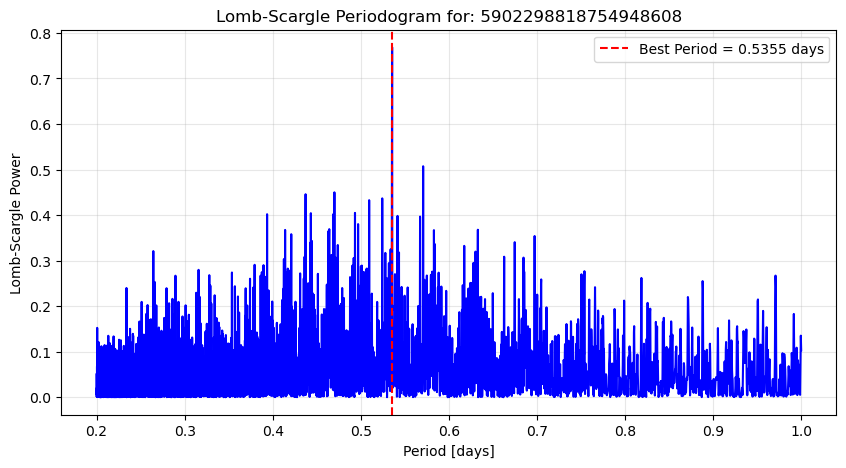

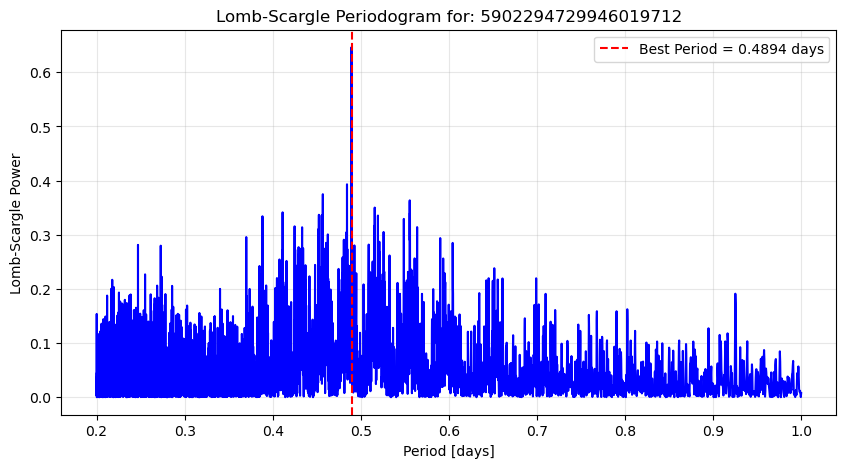

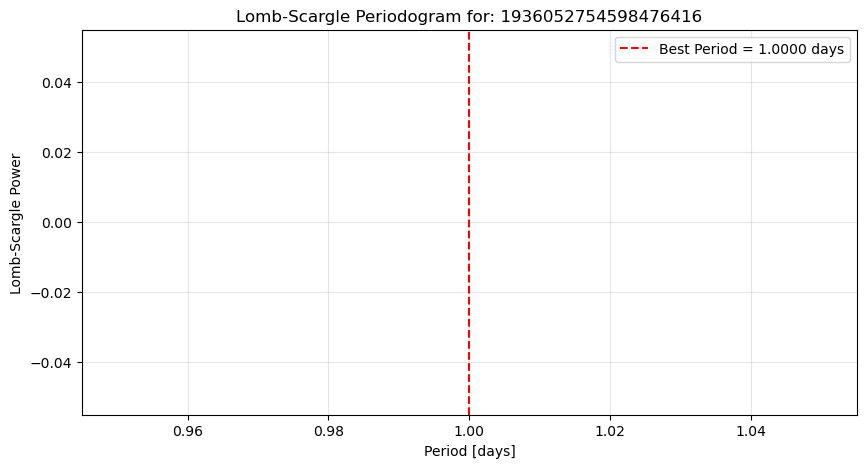

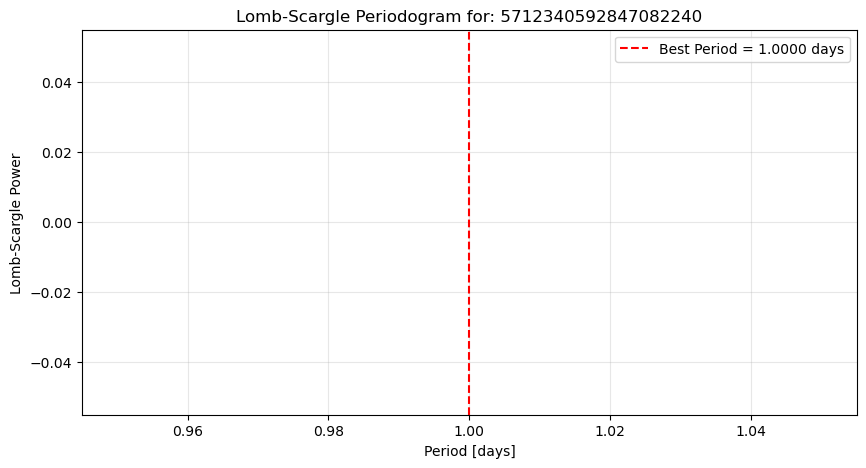

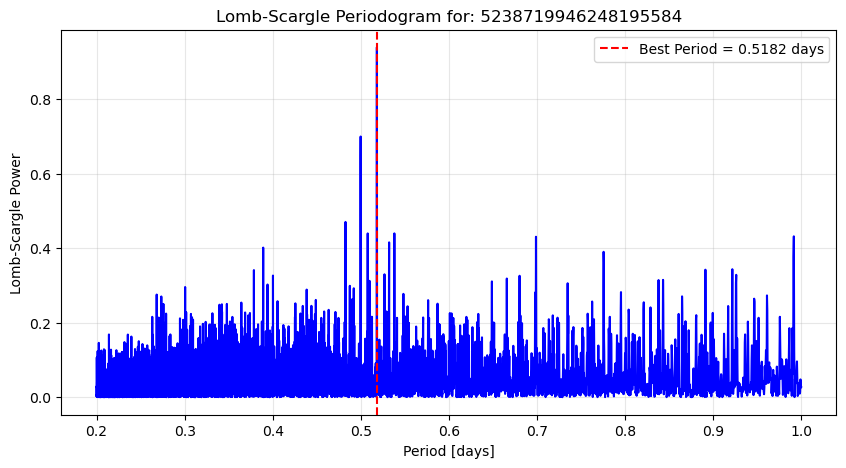

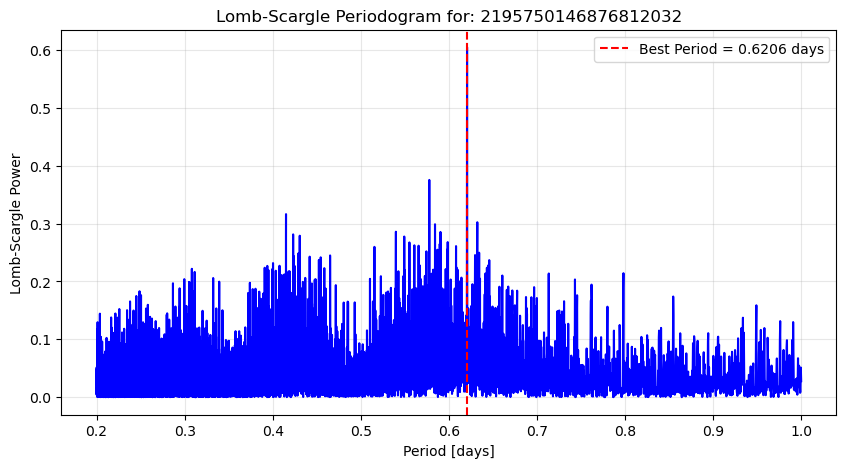

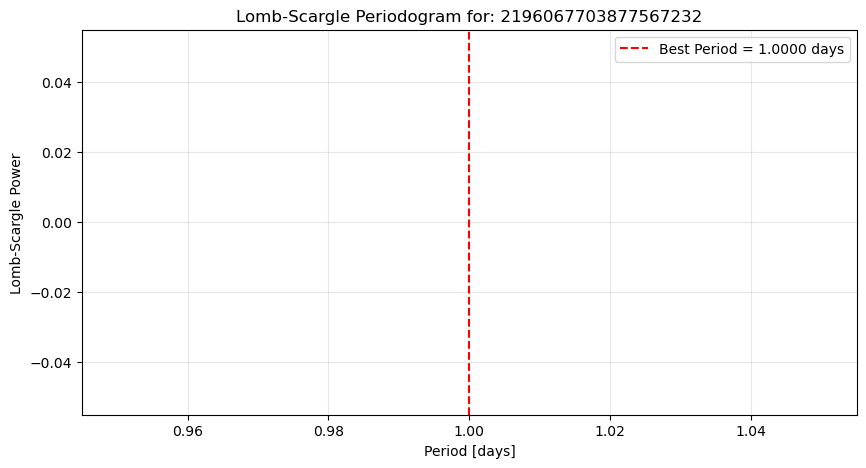

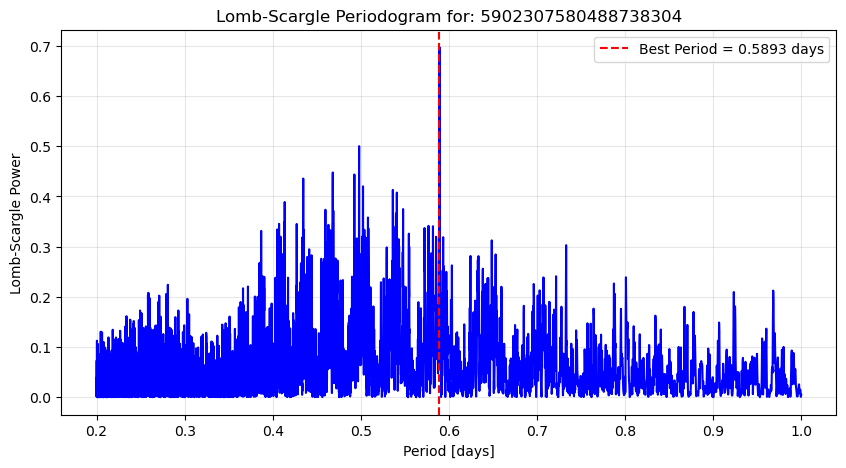

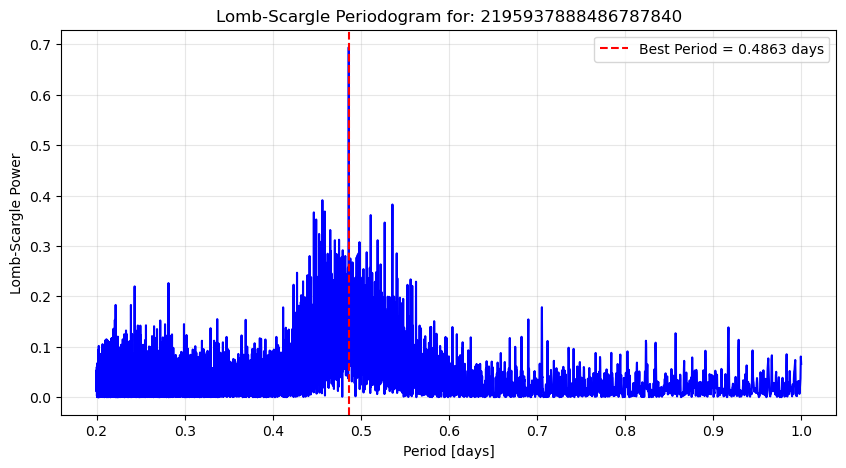

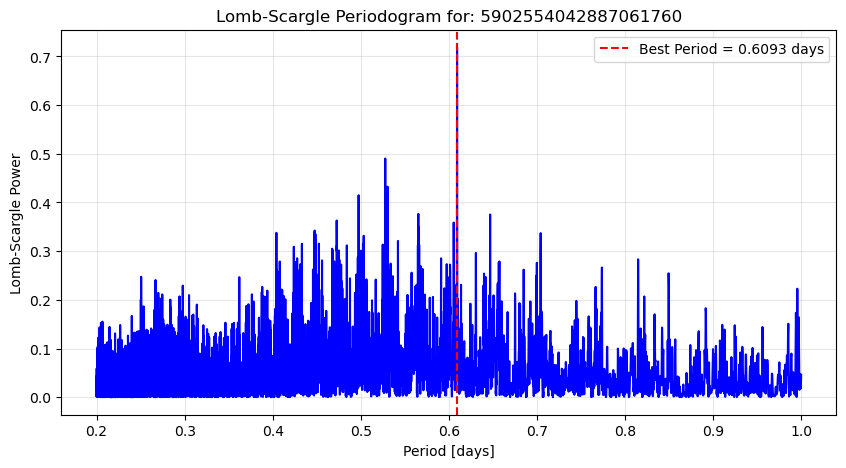

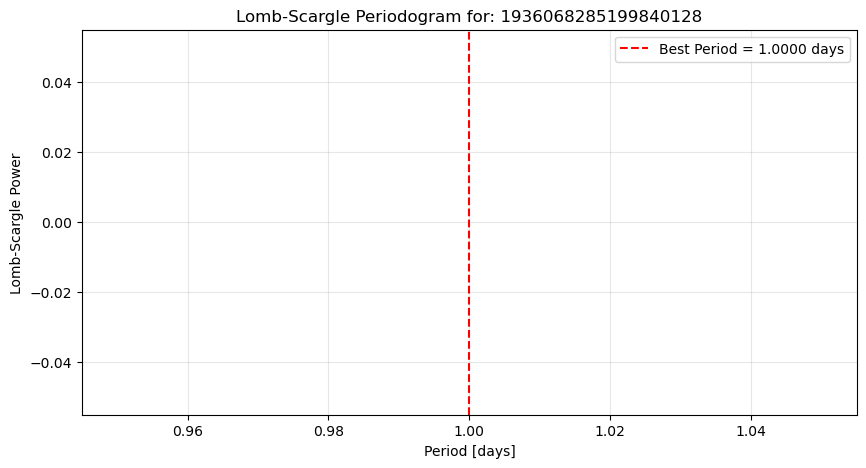

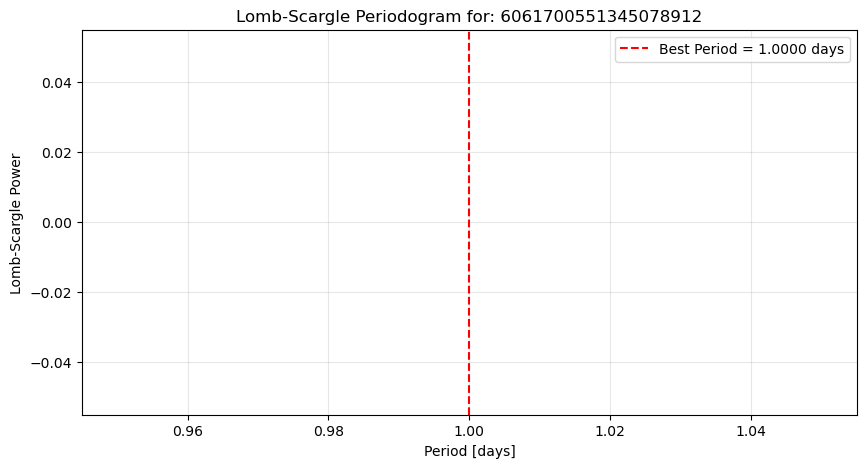

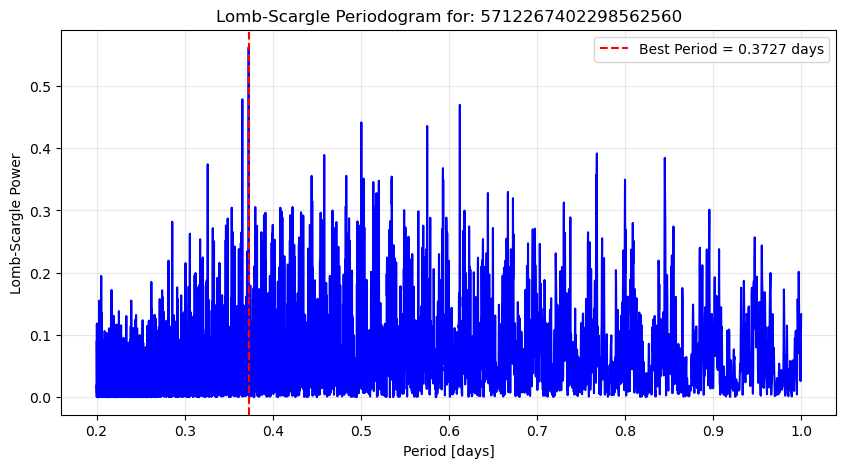

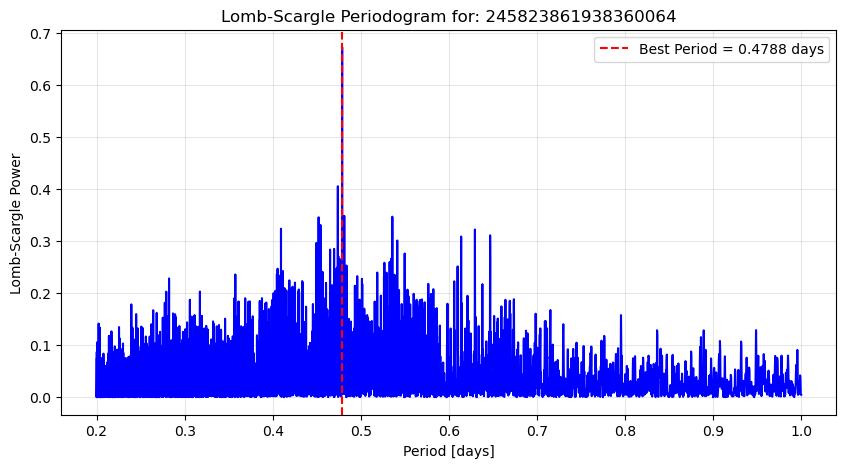

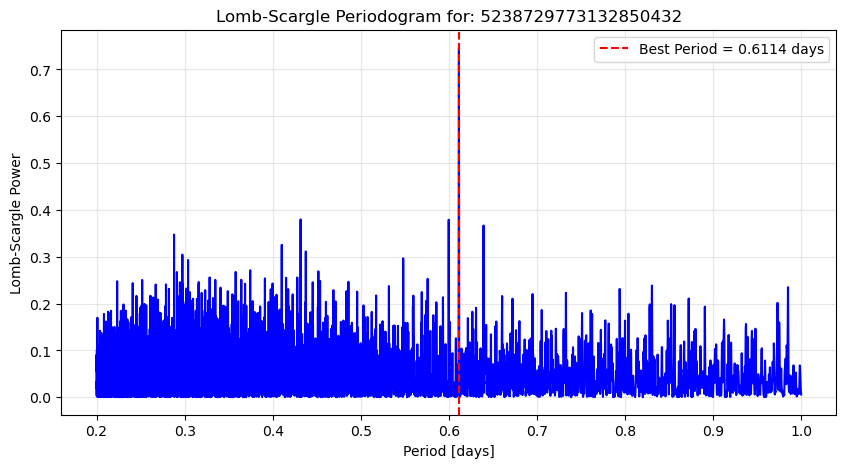

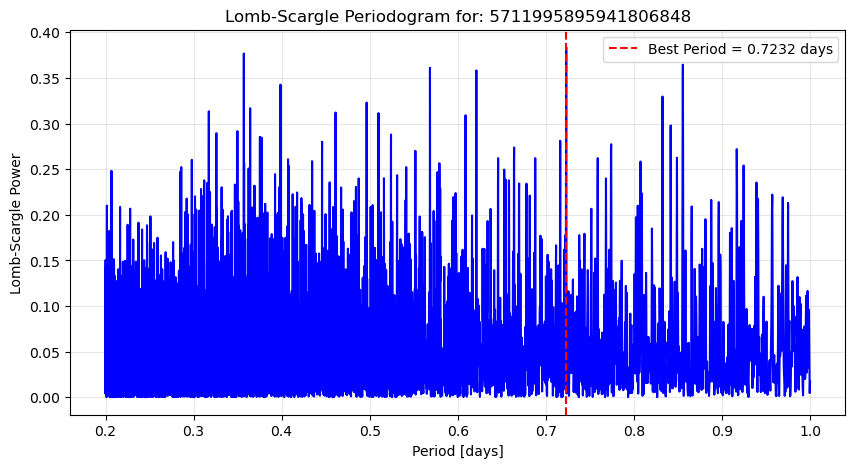

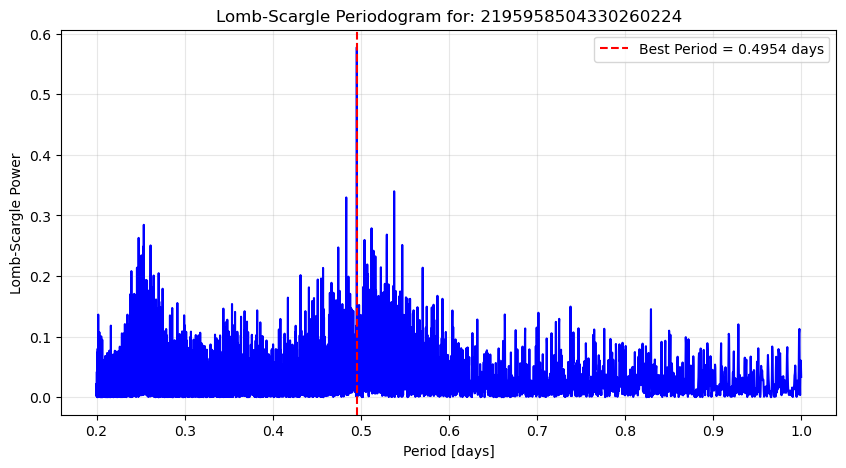

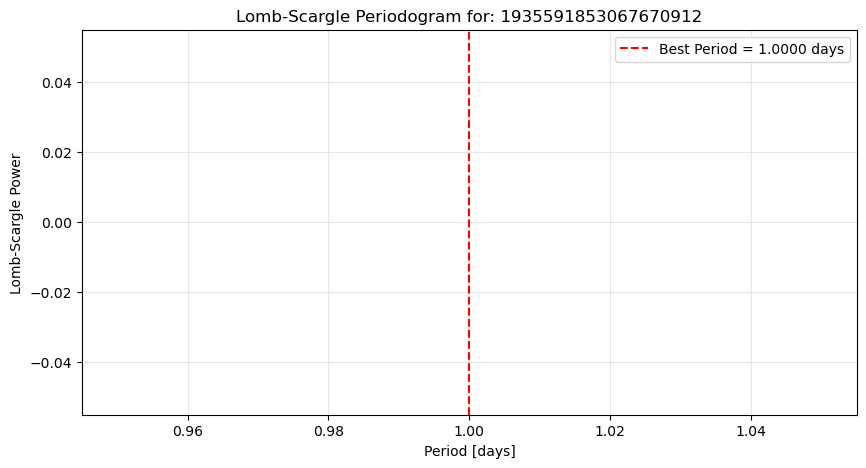

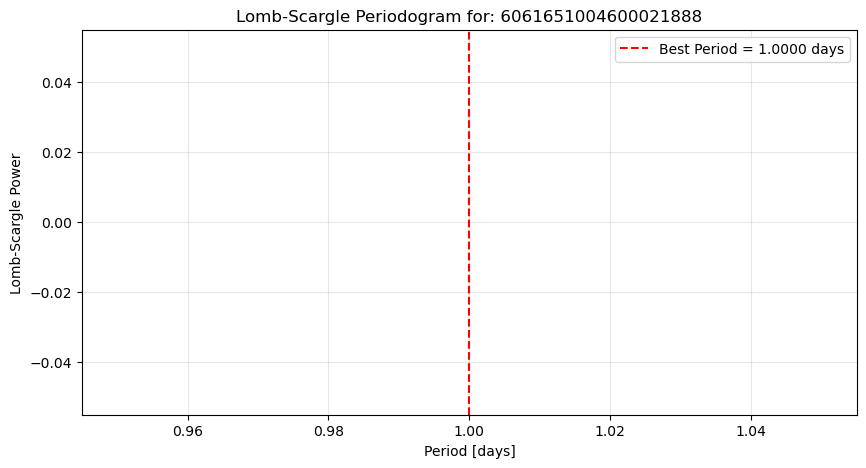

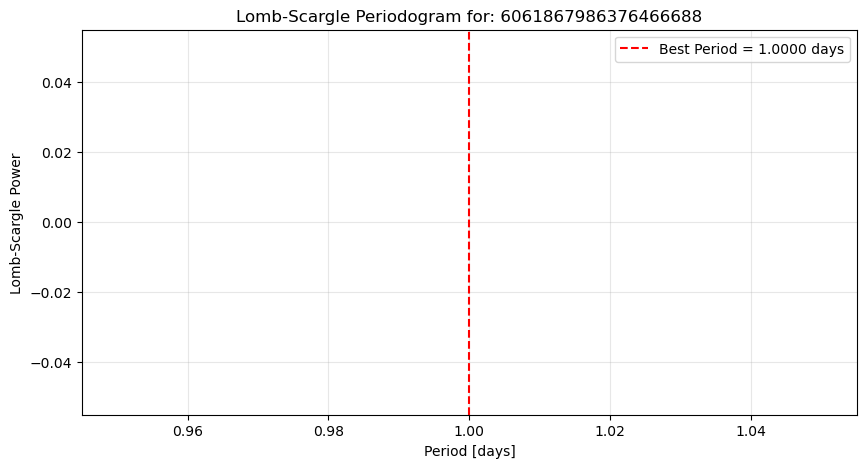

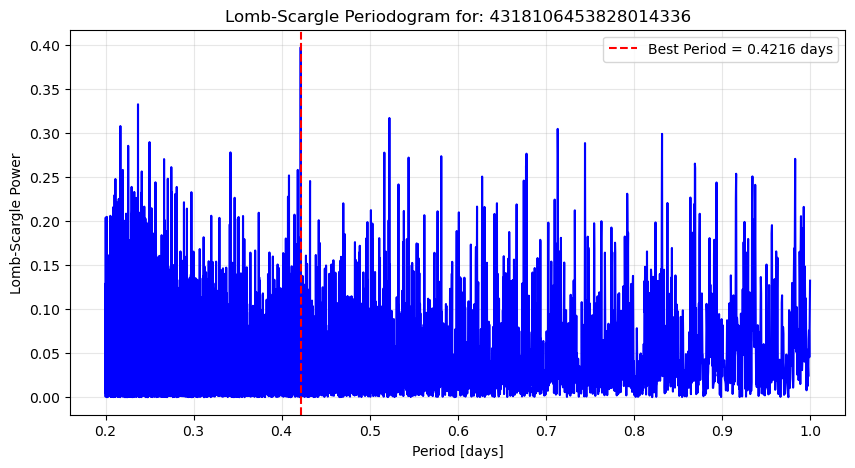

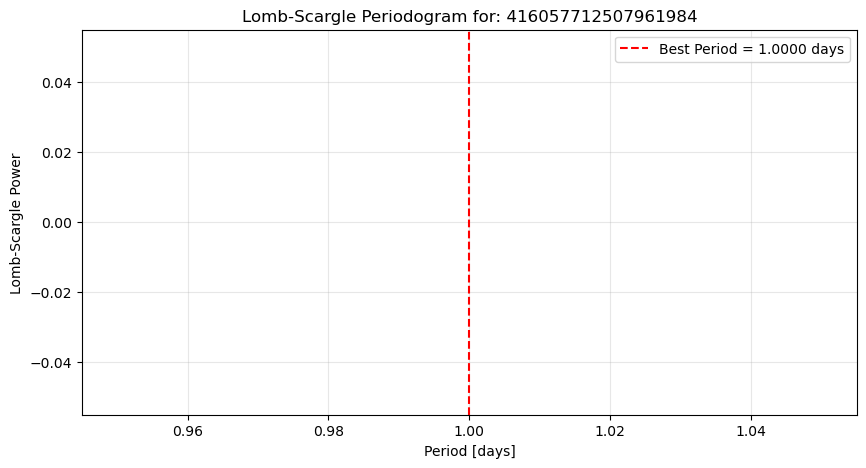

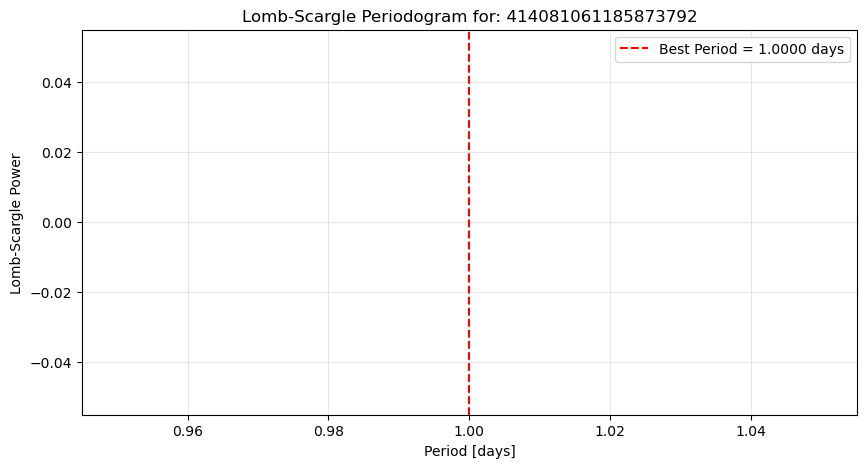

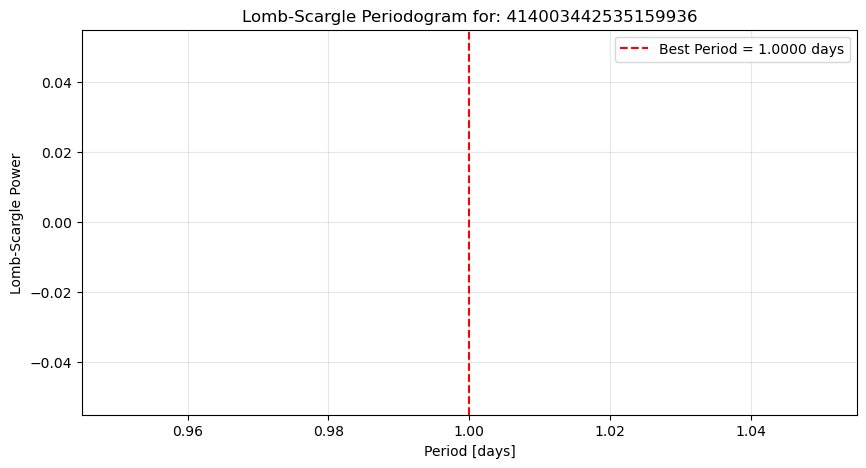

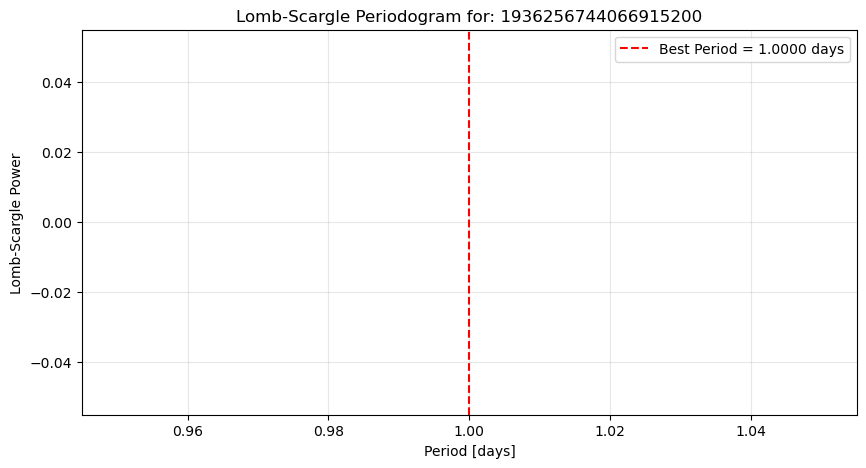

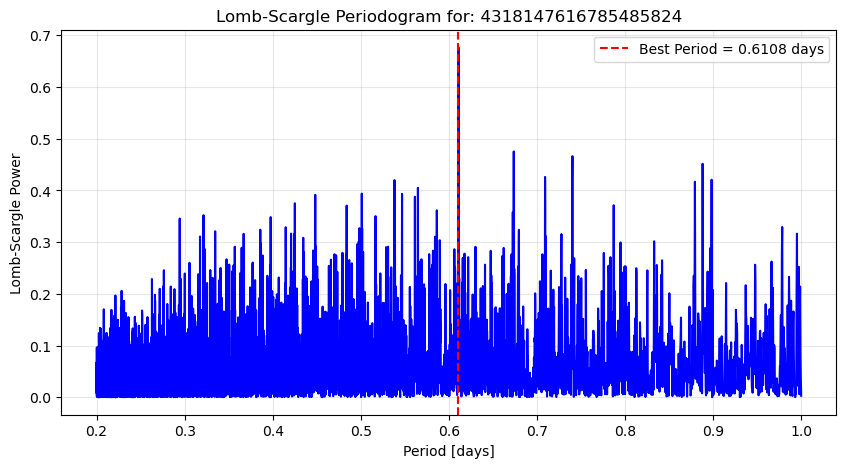

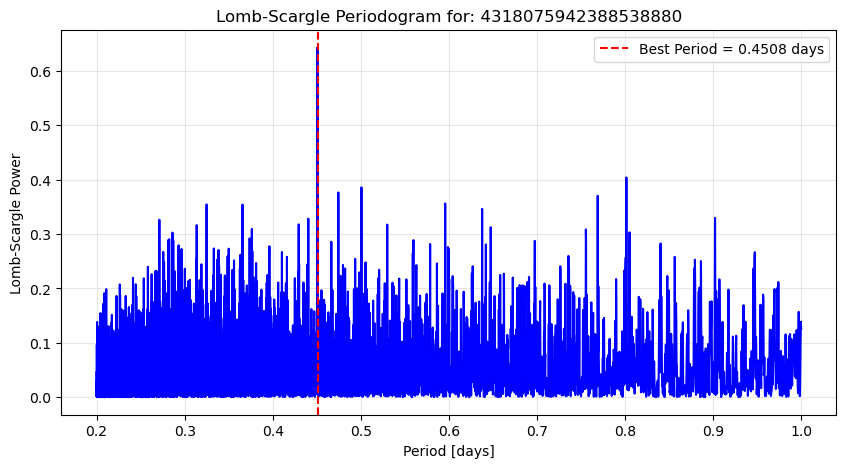

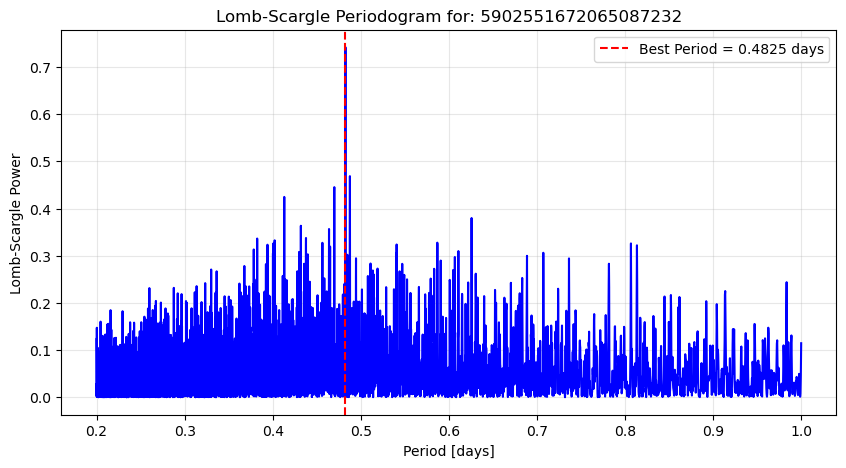

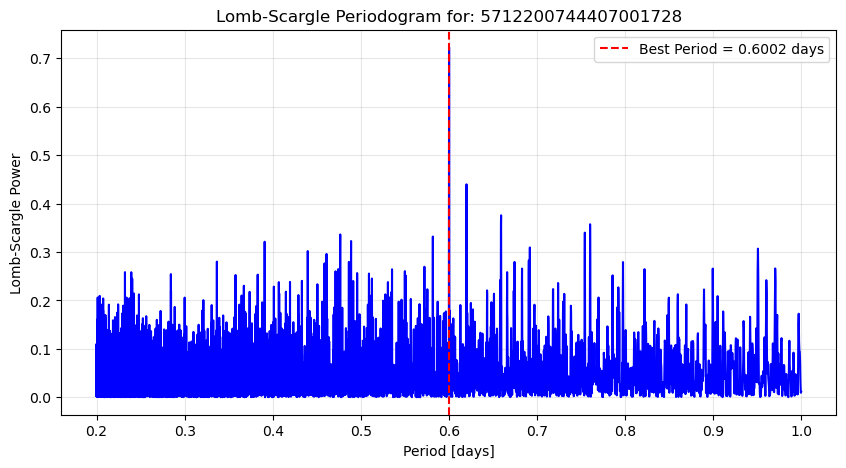

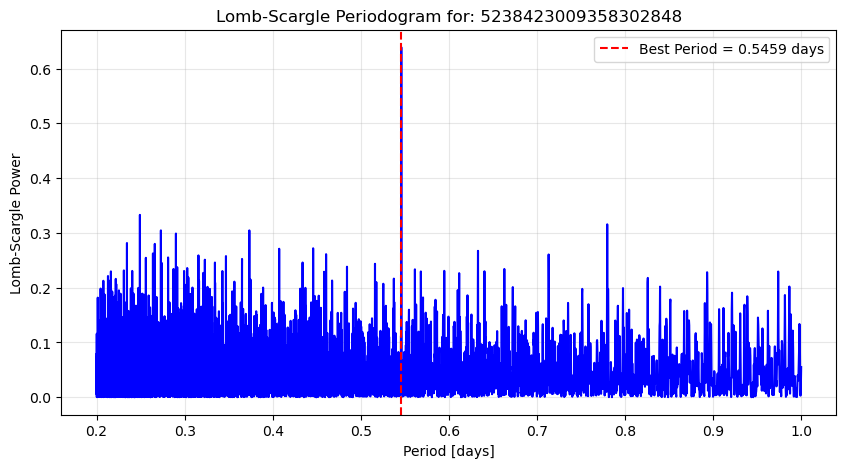

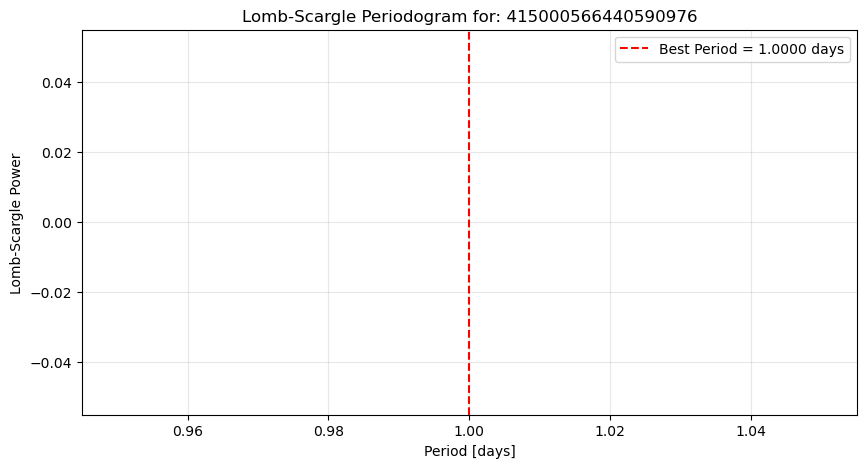

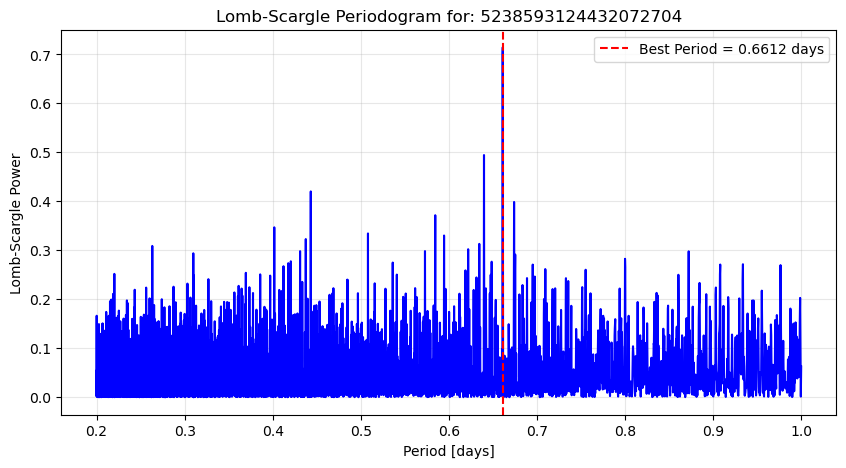

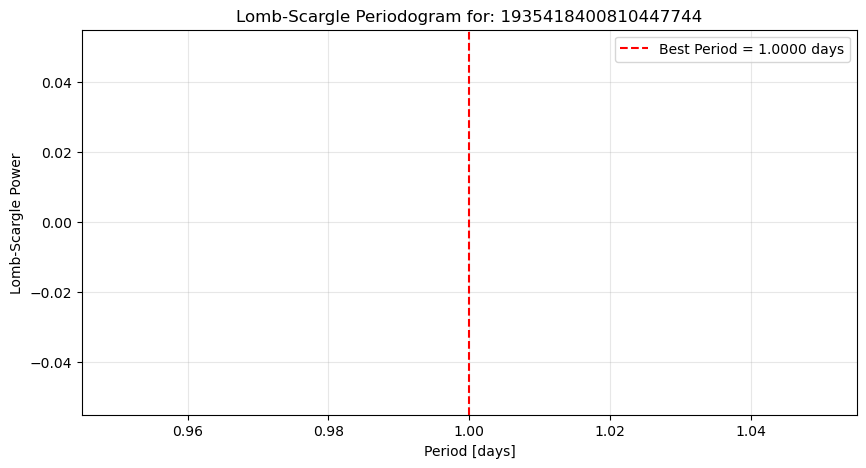

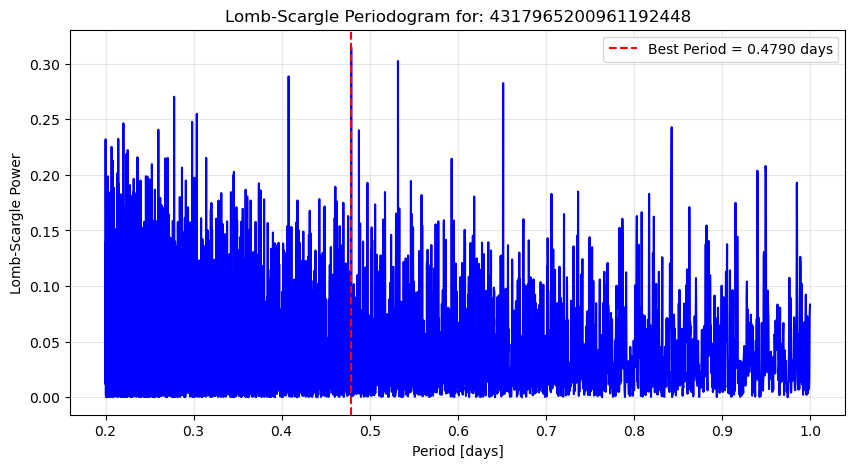

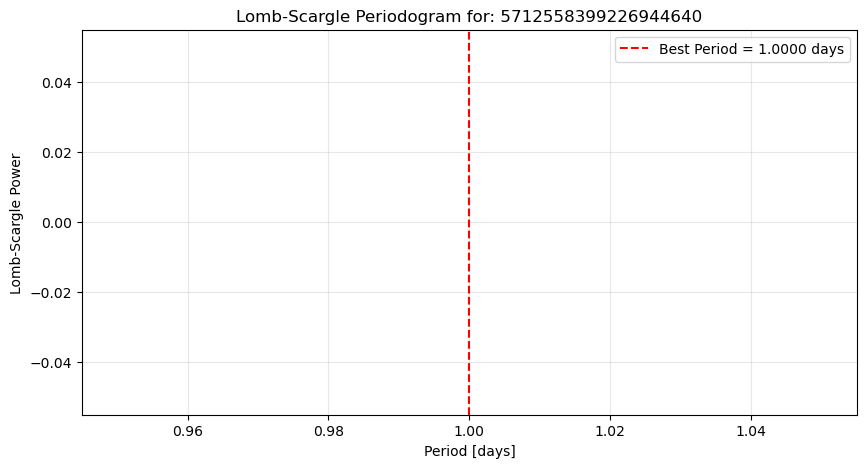

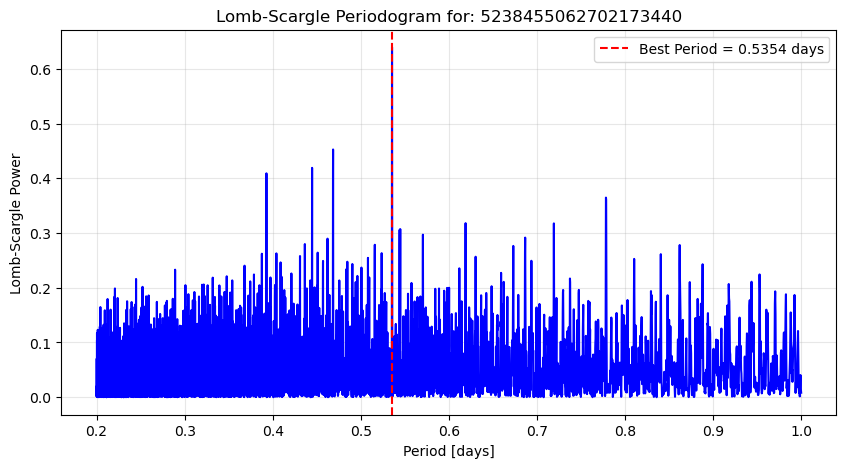

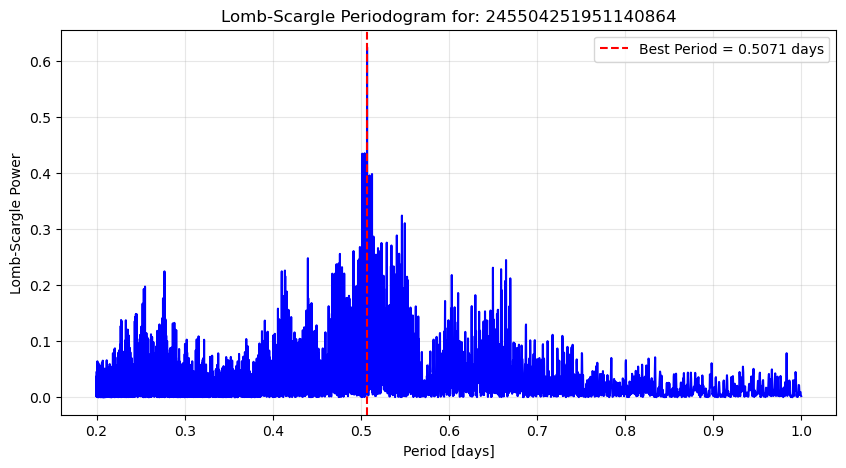

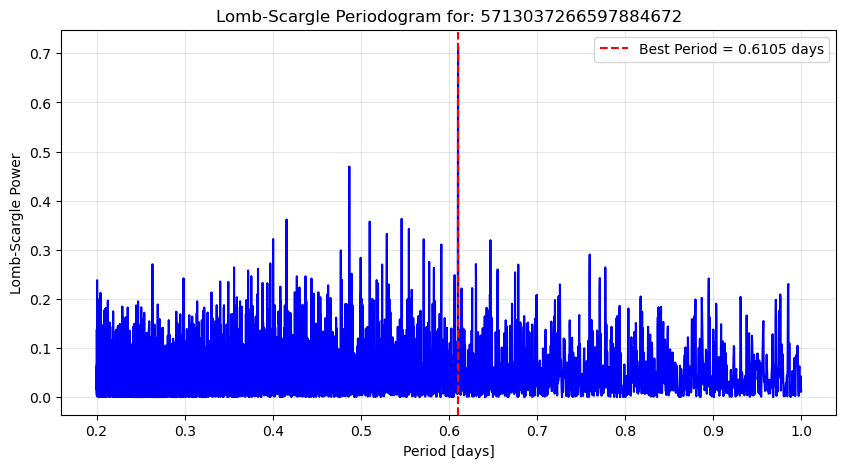

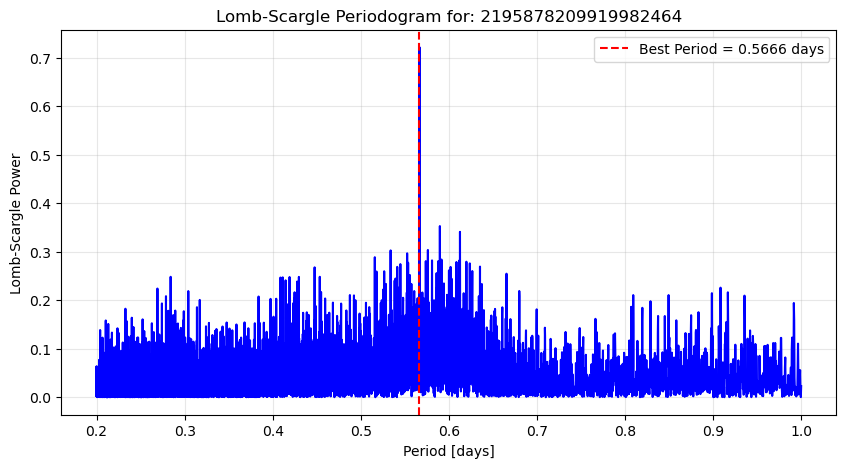

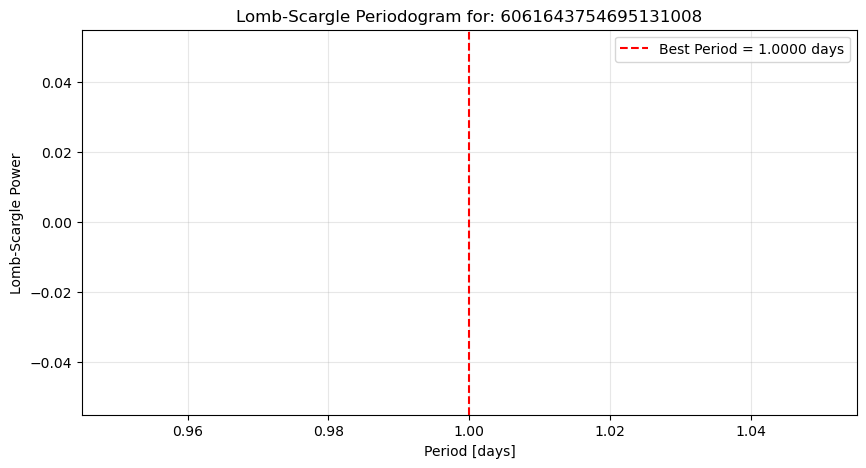

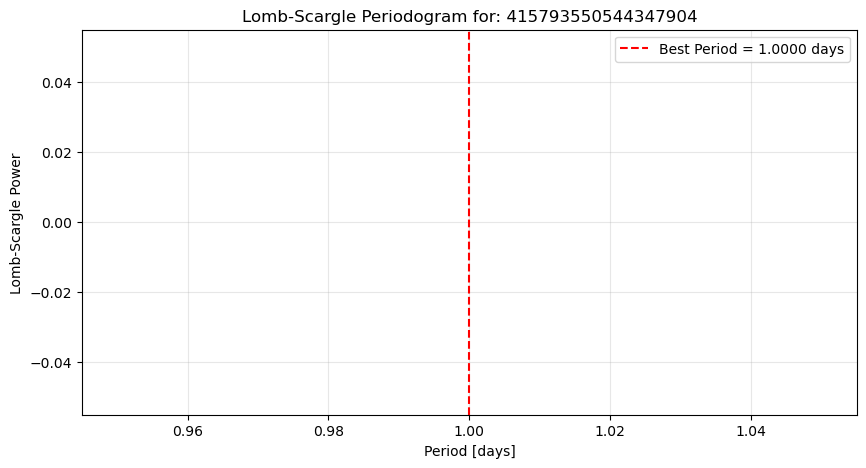

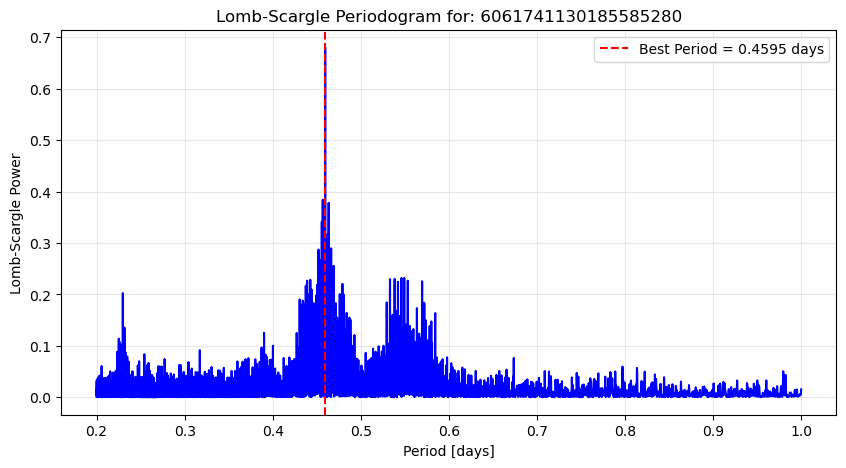

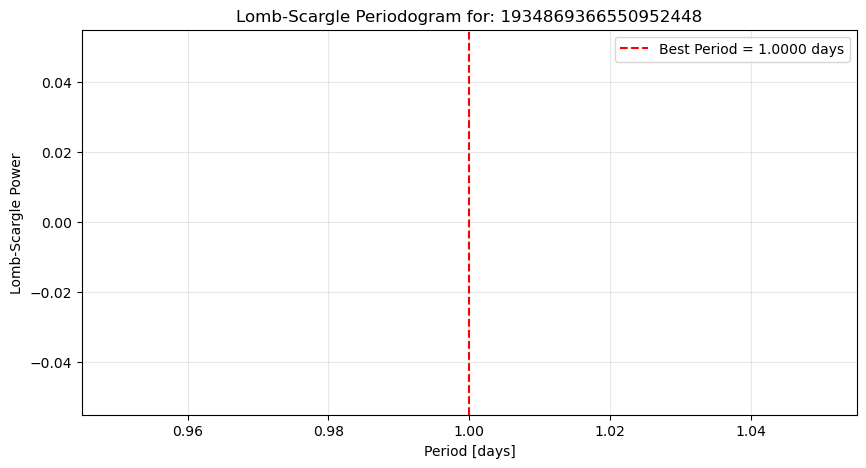

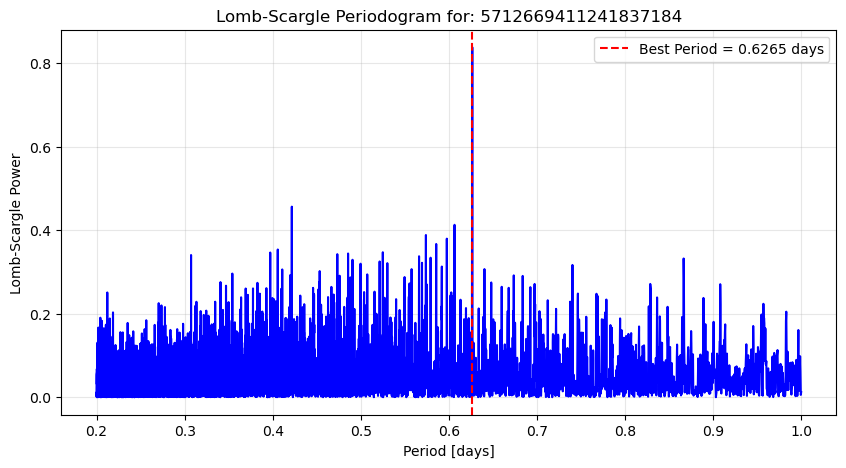

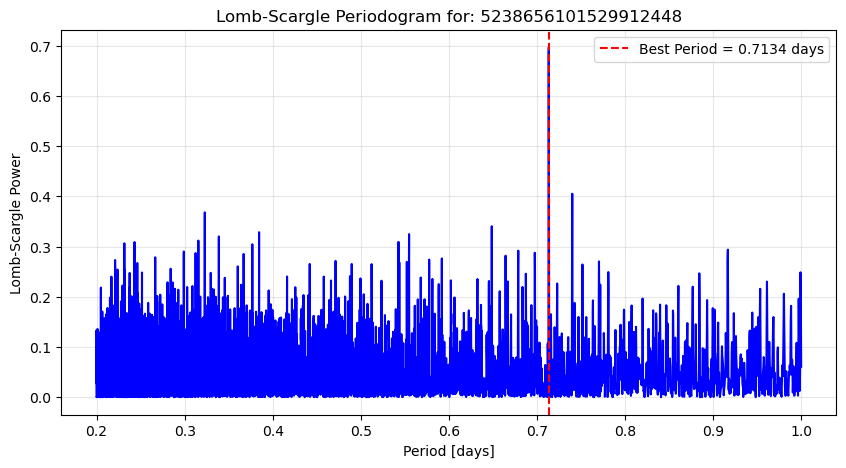

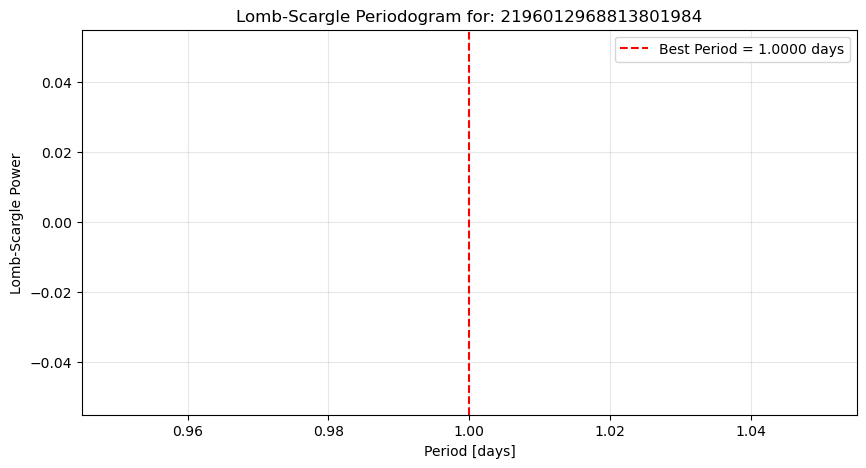

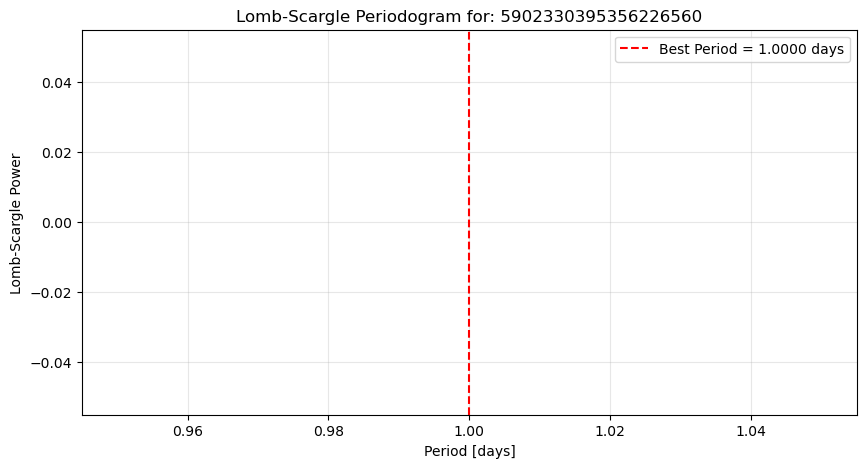

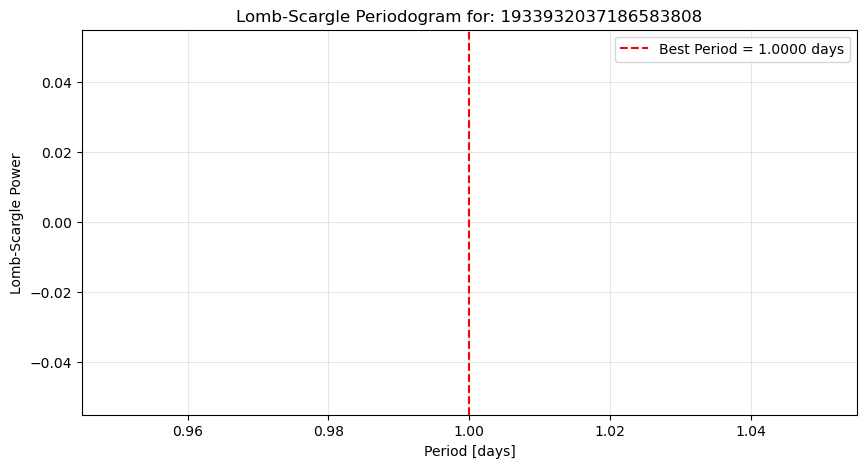

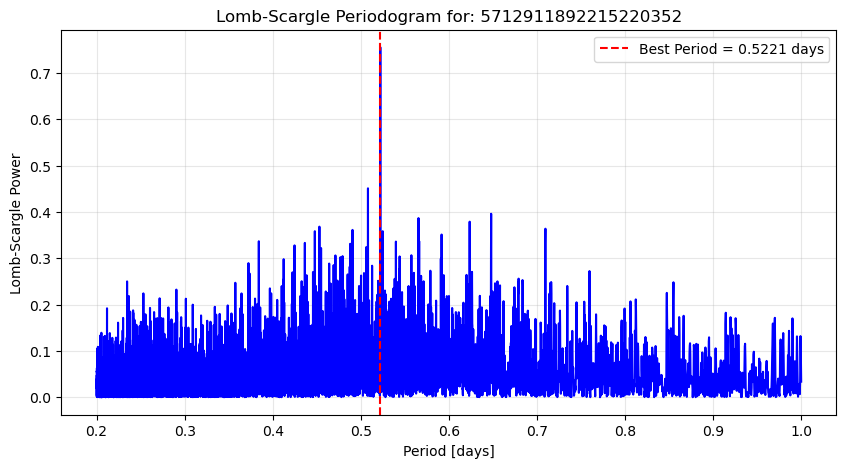

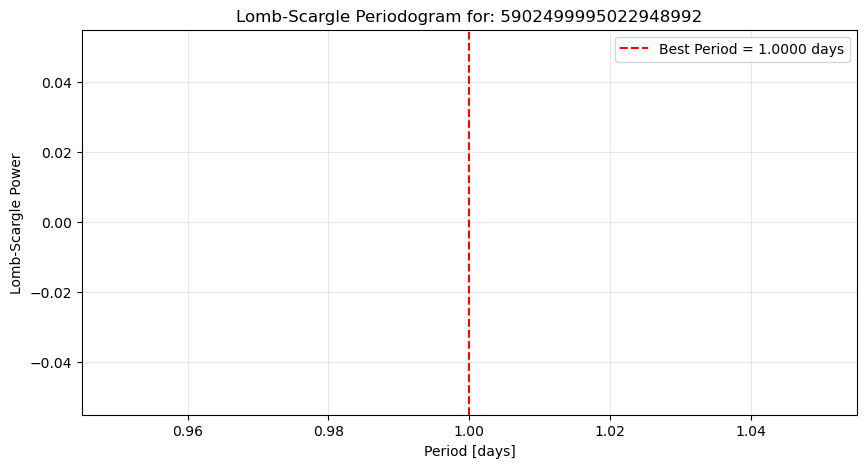

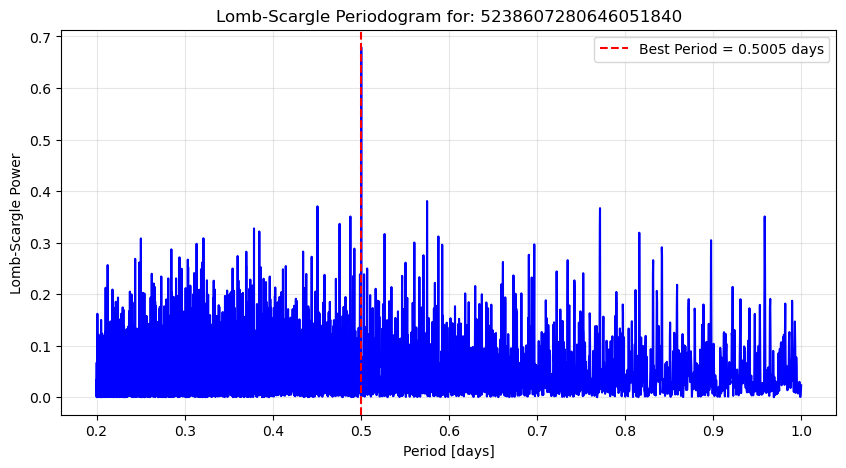

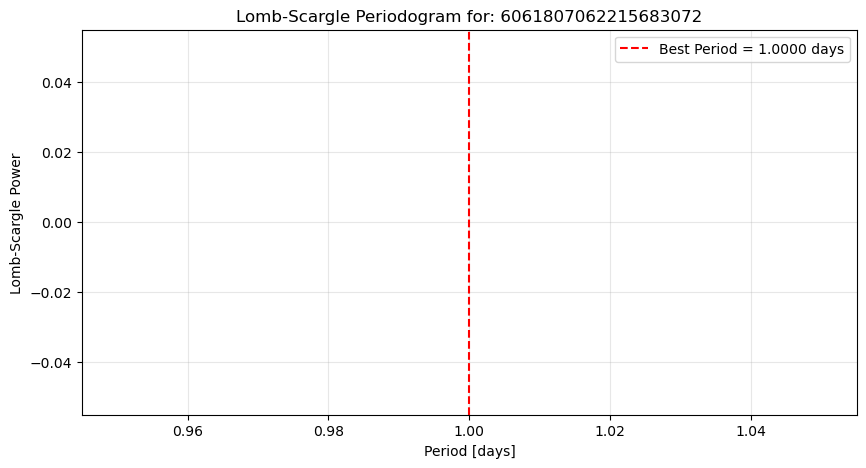

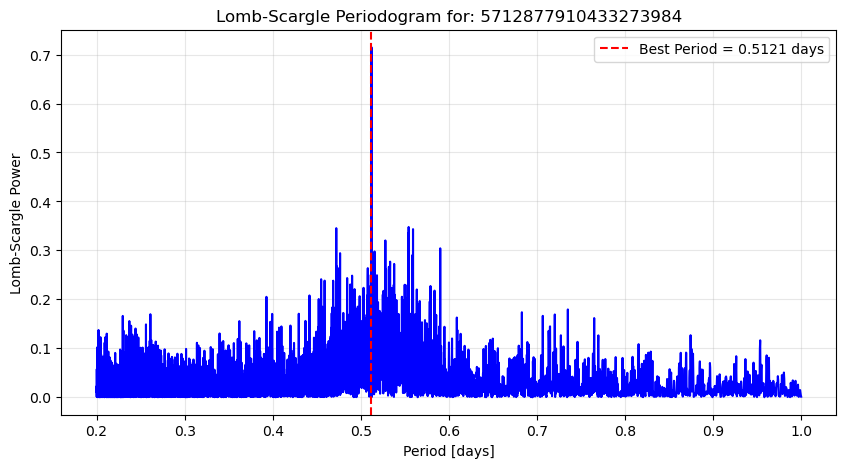

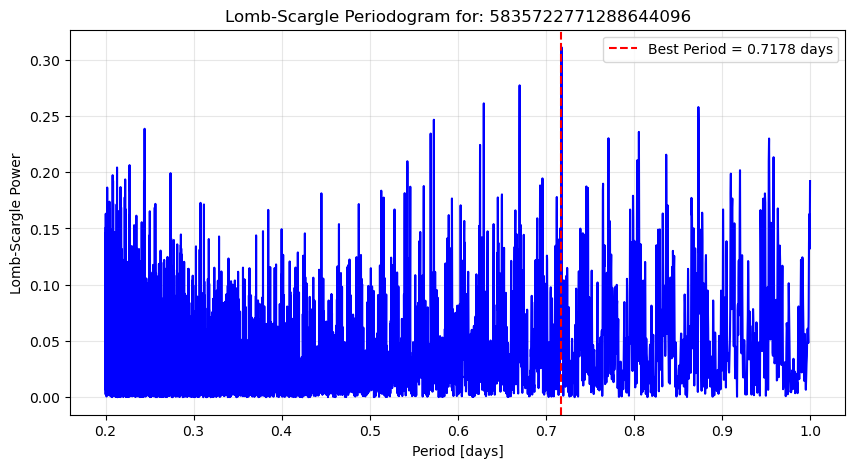

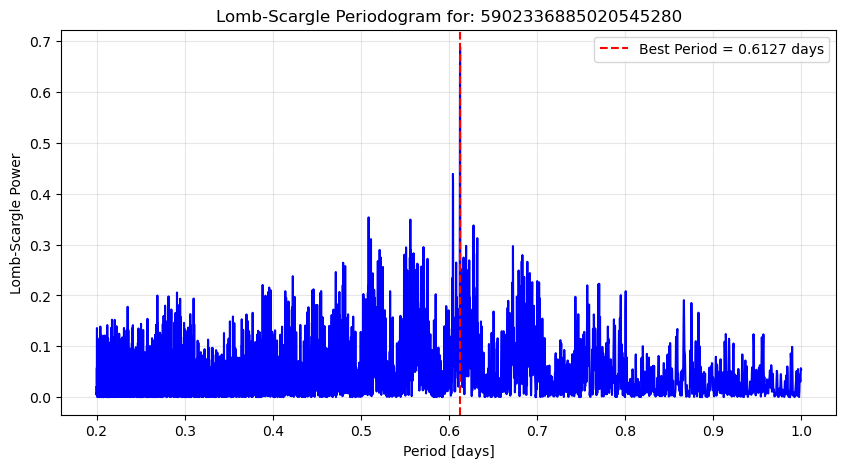

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.timeseries import LombScargle
import astropy.units as u

# Assuming:
# - datalink_out is a dictionary with VOTables
# - source_ids is a list of source IDs you want to analyze

# Store results
periods = []
mean_mags = []
mag_errors = []
processed_sources = []

# Extract source IDs from datalink_out keys
source_ids = [key.split()[-1].replace(".xml", "") for key in datalink_out.keys()]

# Loop through every source ID
for src_id in source_ids:
    # Look through all datalink keys to find matching one
    matching_key = None
    for data_key in datalink_out.keys():
        if str(src_id) in data_key:
            matching_key = data_key
            break  # Stop once match is found
    
    if matching_key is None:
        print(f"[!] No matching key found for source {src_id}")
        continue  # Skip to the next source_id

    try:
        votable = datalink_out[matching_key][0]
        df = votable.to_table().to_pandas()

        # Run your analysis function
        best_period, mean_mag, sigma_mag = analyze_light_curve(df, src_id)

        # Save results
        periods.append(best_period)
        mean_mags.append(mean_mag)
        mag_errors.append(sigma_mag)
        processed_sources.append(src_id)

    except Exception as e:
        print(f"[!] Error processing source {src_id}: {e}")
        continue  # Skip any broken/missing data





In [31]:
results_df = pd.DataFrame({
    "source_id": processed_sources,
    "best_period": periods,
    "mean_mag": mean_mags,
    "mag_error": mag_errors
})

results_df.to_csv("light_curve_results.csv", index=False)


In [32]:
results_df

,source_id,best_period,mean_mag,mag_error
0,359112665277840512,0.501782,15.945795,0.002026
1,5902512467598855040,1.000000,18.873869,0.002644
2,6061866508861866240,0.258245,19.845843,0.003760
3,414254032403091072,1.000000,16.632071,0.002059
4,5712768539085118080,1.000000,17.463883,0.002139
...,...,...,...,...
95,5238607280646051840,0.500475,18.454646,0.002370
96,6061807062215683072,1.000000,19.627874,0.002895
97,5712877910433273984,0.512060,13.188545,0.002005
98,5835722771288644096,0.717752,20.386675,0.005120


In [40]:
results


,source_id,phot_variable_flag,pf,epoch_g
0,245002531050576896,VARIABLE,0.520512,1705.132336
1,245504251951140864,VARIABLE,0.507115,1705.941237
2,245823861938360064,VARIABLE,0.478764,1705.224346
3,246756973652292992,VARIABLE,0.489303,1705.694932
4,359112665277840512,VARIABLE,0.501780,1700.672707
...,...,...,...,...
95,2195958504330260224,VARIABLE,0.495418,1687.147981
96,2195979635570512640,VARIABLE,0.527883,1688.650673
97,2196012968813801984,VARIABLE,0.605841,1687.237710
98,2196067703877567232,VARIABLE,0.575690,1689.219273


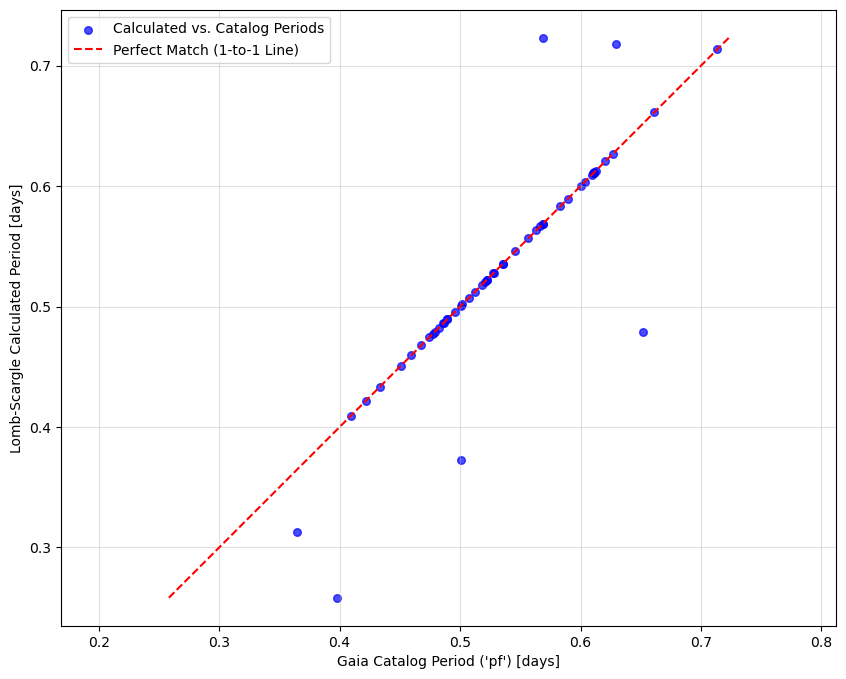

In [44]:
# First, ensure the 'source_id' in your results_df is the correct data type (integer)
results_df['source_id'] = results_df['source_id'].astype('int64')

# Merge the original Gaia data with your calculated results on the 'source_id' column
# This ensures that 'pf' and 'best_period' for each star are on the same row.
merged_df = pd.merge(results, results_df, on='source_id')

# Now, create a boolean mask to filter out the failed 1.0-day calculations
mask = merged_df['best_period'] < 0.999
filtered_df = merged_df[mask]

# --- Plotting from the correctly merged and filtered data ---
plt.figure(figsize=(10, 8))

# Plot calculated period vs. catalog period
plt.scatter(filtered_df['pf'], filtered_df['best_period'], color='blue', alpha=0.7, s=30, label='Calculated vs. Catalog Periods')

# Add the red dashed line for a perfect 1-to-1 match
min_val = min(filtered_df['pf'].min(), filtered_df['best_period'].min())
max_val = max(filtered_df['pf'].max(), filtered_df['best_period'].max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Perfect Match (1-to-1 Line)')

# --- Formatting ---
plt.xlabel("Gaia Catalog Period ('pf') [days]")
plt.ylabel("Lomb-Scargle Calculated Period [days]")
# plt.title("Comparison of Calculated vs. Catalog RR Lyrae Periods")
plt.legend()
plt.grid(alpha=0.4)
plt.axis('equal') # This makes the plot square and the 1-to-1 line a true 45-degree diagonal
plt.savefig('comparsion of pf and period.jpeg')
plt.show()


Estimated period: 0.5205 d days


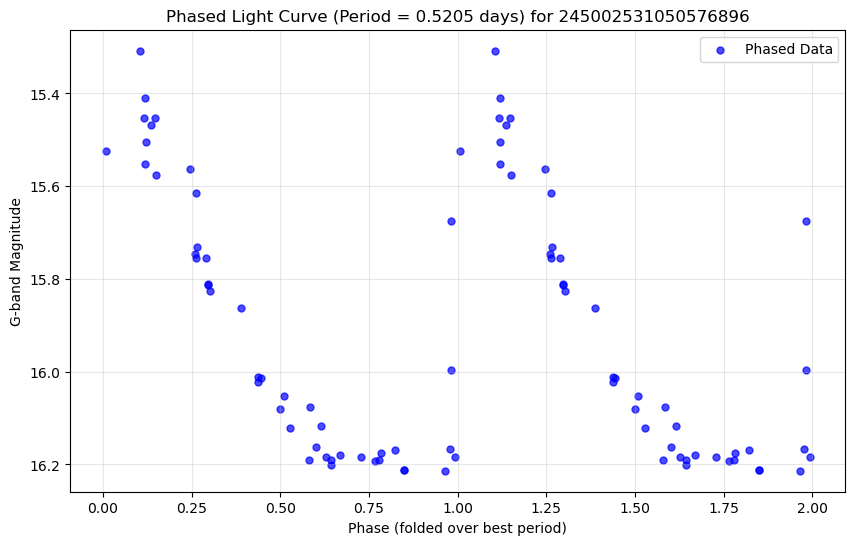

In [45]:
# Extract data
time = votable_data["g_transit_time"]
mag = votable_data["g_transit_mag"]

# === Step 1: Compute Lomb-Scargle Periodogram ===
min_period = 0.2 * u.day
max_period = 1.0 * u.day
frequency = np.linspace(1/max_period, 1/min_period, 10000)

ls = LombScargle(time, mag)
power = ls.power(frequency)

# Find the frequency with the highest power
best_frequency = frequency[np.argmax(power)]
best_period = 1 / best_frequency

print(f"Estimated period: {best_period:.4f} days")

# === Step 2: Phase-fold the light curve ===
# Phase = fractional part of (time / best_period)
phase = (time % best_period.value) / best_period.value

# Optional: sort by phase for a smoother plot
sorted_indices = np.argsort(phase)
phase_sorted = phase[sorted_indices]
mag_sorted = mag[sorted_indices]

# === Step 3: Plot phased light curve ===
plt.figure(figsize=(10, 6))
plt.scatter(phase_sorted, mag_sorted, color='blue', alpha=0.7, s=25, label="Phased Data")

# Repeat the phase curve from 1 → 2 for clarity
plt.scatter(phase_sorted +1 , mag_sorted, color='blue', alpha=0.7, s=25)

plt.gca().invert_yaxis()  # Brightness increases upward
plt.xlabel("Phase (folded over best period)")
plt.ylabel("G-band Magnitude")
plt.title(f"Phased Light Curve (Period = {best_period.value:.4f} days) for {source_id}")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


Estimated period = 0.520483 days  (frequency = 1.921292 1/day)
K=1: RMS residual = 0.14410 mag


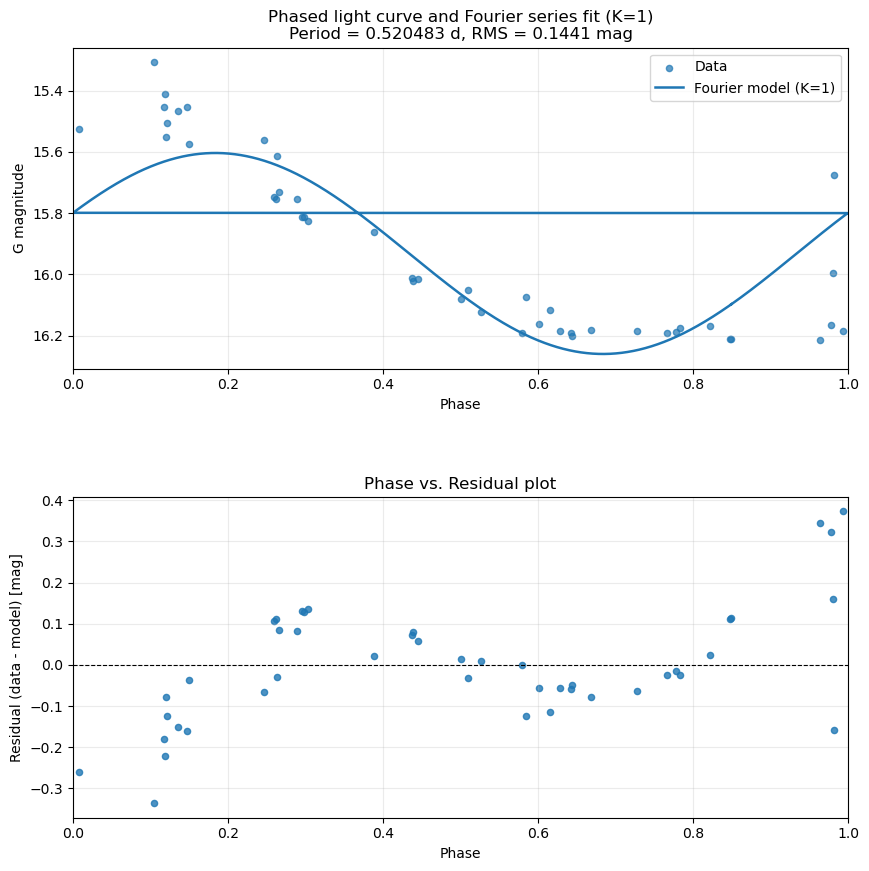

K=3: RMS residual = 0.09832 mag


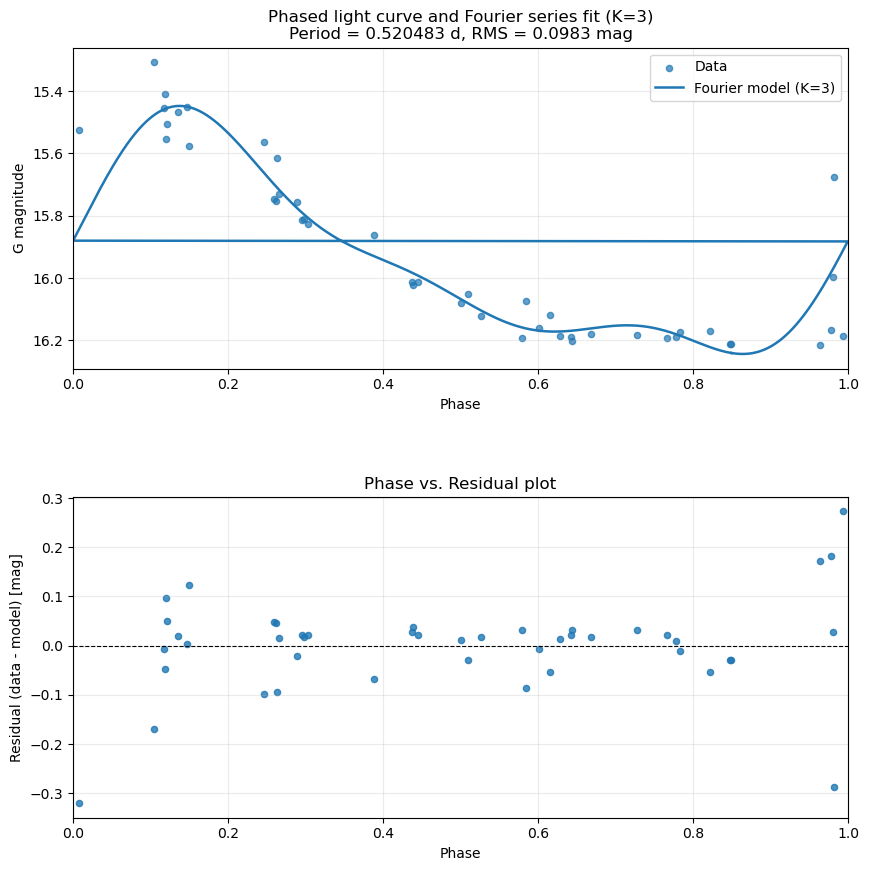

K=5: RMS residual = 0.08776 mag


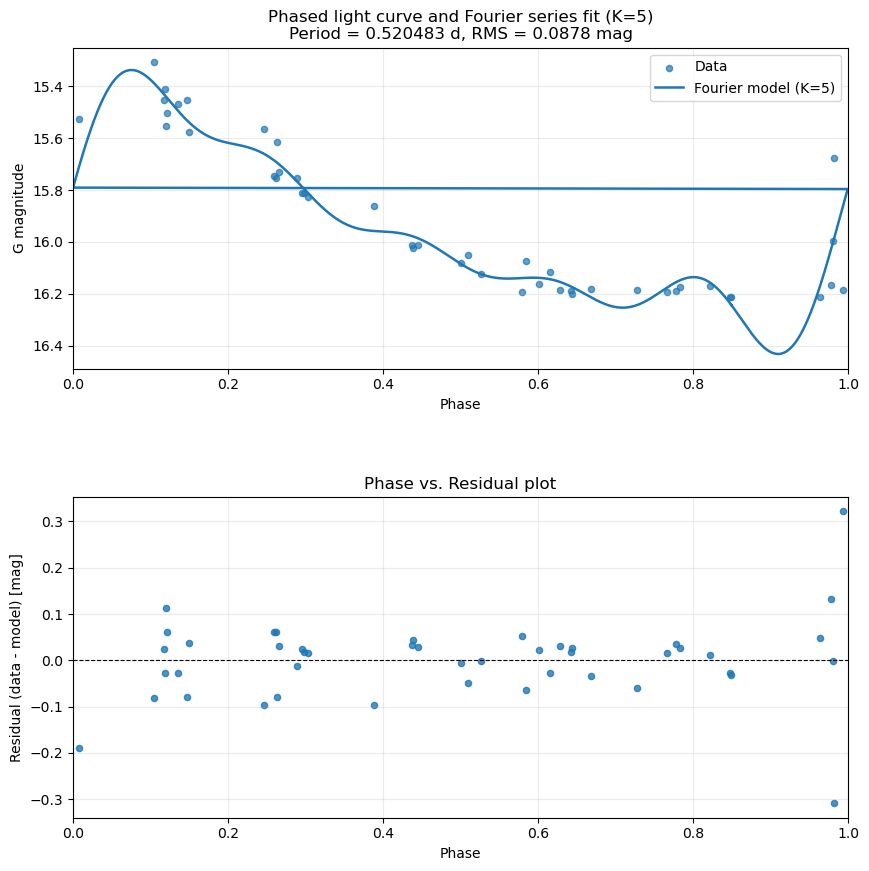

K=7: RMS residual = 0.08216 mag


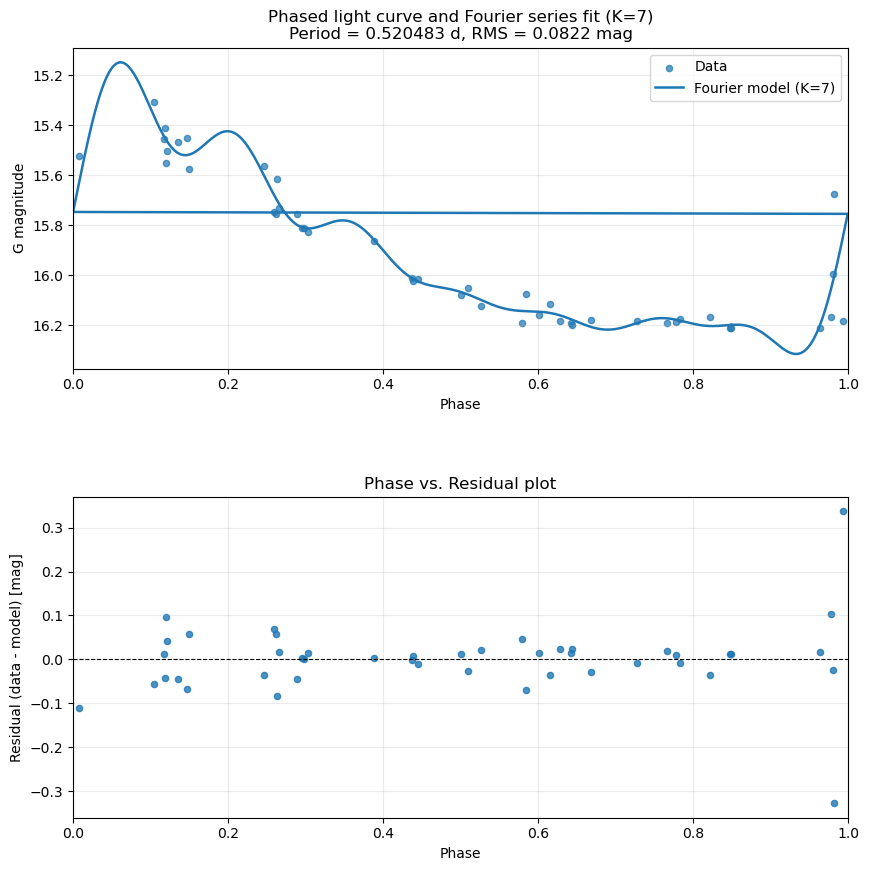

K=9: RMS residual = 0.08066 mag


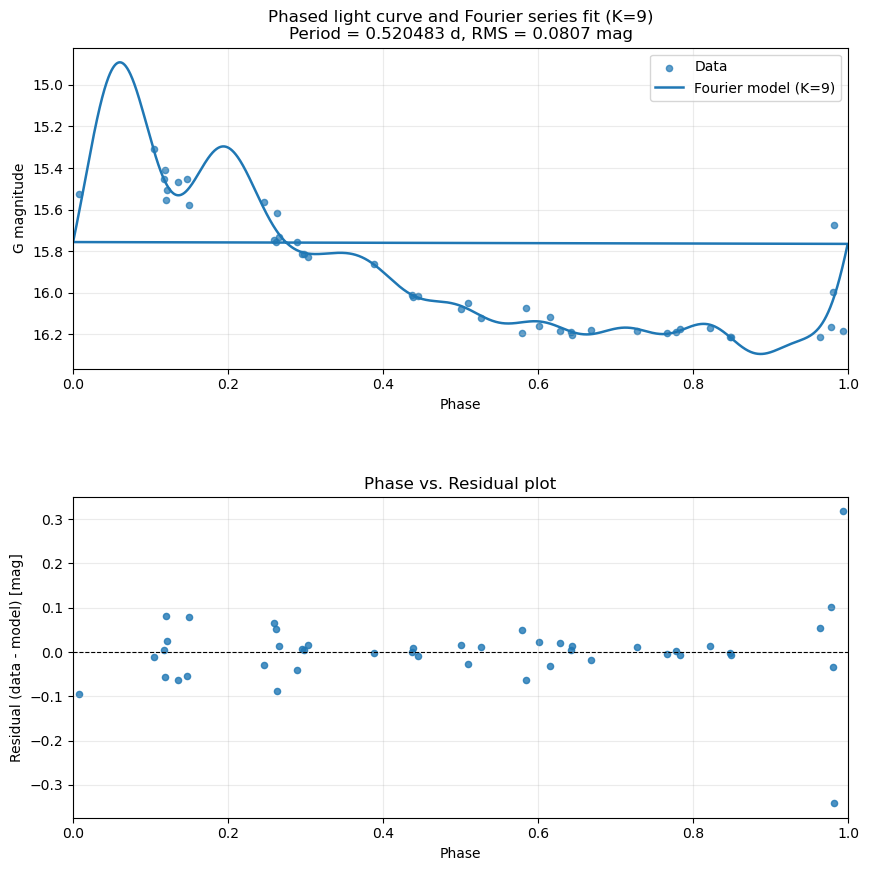

Summary RMS by K: {1: 0.1441008367157587, 3: 0.09832461226041275, 5: 0.08775583798540293, 7: 0.08215966152521424, 9: 0.08066423833290605}


In [47]:
# --- USER: replace votable_data with your actual table variable if different ---
time = np.array(votable_data["g_transit_time"])       # times in days
mag  = np.array(votable_data["g_transit_mag"])        # magnitudes
# optional: mag_err if available:
mag_err = None
if "g_transit_mag_error" in votable_data.colnames:
    mag_err = np.array(votable_data["g_transit_mag_error"])

# === 1) Estimate best period with Lomb-Scargle (same approach as before) ===
min_period = 0.2 * u.day
max_period = 1.0 * u.day
frequency = np.linspace((1.0/max_period).value, (1.0/min_period).value, 10000)  # in 1/day

ls = LombScargle(time, mag)
power = ls.power(frequency)
best_freq = frequency[np.argmax(power)]
best_period = 1.0 / best_freq
omega = 2 * np.pi / best_period  # angular frequency in rad/day

print(f"Estimated period = {best_period:.6f} days  (frequency = {best_freq:.6f} 1/day)")

# === helper: build design matrix for given times and K ===
def design_matrix(times, K, omega):
    """
    times: array (days)
    K: integer
    omega: angular frequency (rad/day)
    returns X (N x (2K+1)) with columns: [1, sin(1*omega t), ..., sin(K*omega t), cos(1*omega t), ..., cos(K*omega t)]
    """
    t = np.asarray(times).reshape(-1)
    N = t.size
    cols = [np.ones(N)]
    for k in range(1, K+1):
        cols.append(np.sin(k * omega * t))
    for k in range(1, K+1):
        cols.append(np.cos(k * omega * t))
    X = np.vstack(cols).T
    return X

# === Phase for plotting (0..1) and sorted order ===
phase = (time % best_period) / best_period
order = np.argsort(phase)
phase_sorted = phase[order]
mag_sorted = mag[order]

# K values to try
K_values = [1, 3, 5, 7, 9]

# Fine time grid to show model (one period, then repeat to 2 periods)
t_grid = np.linspace(time.min(), time.min() + best_period, 2000)         # times across one period
phase_grid = (t_grid % best_period) / best_period   # 0..1

# We'll store RMS residuals
rms_results = {}

for K in K_values:
    # build design matrices
    X = design_matrix(time, K, omega)            # for observed times
    X_grid = design_matrix(t_grid, K, omega)     # for plotting the model on fine grid

    # Solve least squares for beta
    beta, *_ = np.linalg.lstsq(X, mag, rcond=None)   # shape (2K+1,)
    # predicted magnitudes at observation times and on the grid
    mag_model = X.dot(beta)
    mag_grid = X_grid.dot(beta)

    # residuals and RMS
    resid = mag - mag_model
    rms = np.sqrt(np.mean(resid**2))
    rms_results[K] = rms
    print(f"K={K}: RMS residual = {rms:.5f} mag")

    # ========== PLOTTING ==========
    # Create a figure with 2 rows and 1 column for the subplots
    fig = plt.figure(figsize=(10, 10)) # Increased height for better spacing
    gs = fig.add_gridspec(2, 1, hspace=0.4) # 2 rows, 1 col, with more vertical space
    
    # --- Top plot: phased data + model ---
    ax0 = fig.add_subplot(gs[0])
    
    # scatter phased data only in [0, 1]
    ax0.scatter(phase_sorted, mag_sorted, s=20, alpha=0.7, label="Data")
    
    # model: show only one period
    phase_model = phase_grid
    ax0.plot(phase_model, mag_grid, lw=1.8, label=f'Fourier model (K={K})')
    
    # Formatting
    ax0.invert_yaxis()
    ax0.set_xlim(0, 1)
    ax0.set_xlabel("Phase")
    ax0.set_ylabel("G magnitude")
    ax0.set_title(f"Phased light curve and Fourier series fit (K={K})\n"
              f"Period = {best_period:.6f} d, RMS = {rms:.4f} mag")
    ax0.legend()
    ax0.grid(alpha=0.25)
    
    # --- Bottom: residuals vs phase ---
    ax1 = fig.add_subplot(gs[1])
    ax1.scatter(phase_sorted, resid[order], s=20, alpha=0.8)
    ax1.axhline(0, color='k', lw=0.8, ls='--')
    ax1.set_xlabel("Phase")
    ax1.set_ylabel("Residual (data - model) [mag]")
    ax1.set_xlim(0, 1) # keep residuals aligned with one period
    ax1.grid(alpha=0.25)
    ax1.set_title("Phase vs. Residual plot")
    
    plt.show()

# Print summary RMS
print("Summary RMS by K:", rms_results)


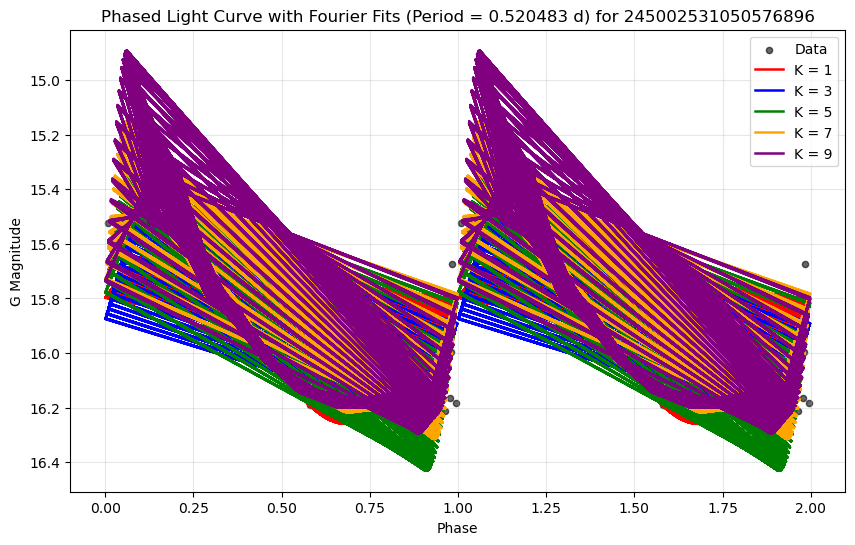

In [48]:

# Fine time grid for the model
# --- USER: replace votable_data with your actual table variable if different ---
time = np.array(votable_data["g_transit_time"])       # times in days
mag  = np.array(votable_data["g_transit_mag"])        # magnitudes

t_grid = np.linspace(time.max(), time.min() + best_period_val, 2000)
phase_grid = (t_grid % best_period_val) / best_period_val


omega = 2 * np.pi / best_period_val 

# --- Phase for plotting ---
phase = (time % best_period_val) / best_period_val
order = np.argsort(phase)
phase_sorted = phase[order]
mag_sorted = mag[order]


# Start a single figure
plt.figure(figsize=(10, 6))

# Plot data points (only once)
plt.scatter(phase_sorted, mag_sorted, s=20, alpha=0.6, color="black", label="Data")
plt.scatter(phase_sorted + 1.0, mag_sorted, s=20, alpha=0.6, color="black")  # duplicate for 0-2 phase

# Loop over K values and plot each model
colors = ["red", "blue", "green", "orange", "purple"]  # different colors for each K
K_values = [1, 3, 5, 7, 9]

# === helper: build design matrix for given times and K ===
def design_matrix(times, K, omega):
    """
#     times: array (days)
#     K: integer
#     omega: angular frequency (rad/day)
#     returns X (N x (2K+1)) with columns: [1, sin(1*omega t), ..., sin(K*omega t), cos(1*omega t), ..., cos(K*omega t)]
#     """
    t = np.asarray(times).reshape(-1)
    N = t.size
    cols = [np.ones(N)]
    for k in range(1, K+1):
         cols.append(np.sin(k * omega * t))
    for k in range(1, K+1):
         cols.append(np.cos(k * omega * t))
    X = np.vstack(cols).T
    
    return X


for i, K in enumerate(K_values):
    # Build design matrix
    X = design_matrix(time, K, omega)
    X_grid = design_matrix(t_grid, K, omega)
    
    # Solve least-squares
    beta, *_ = np.linalg.lstsq(X, mag, rcond=None)
    mag_grid = X_grid @ beta  # predicted model on fine grid

    # Plot model curve (repeat for two phase cycles)
    plt.plot(phase_grid, mag_grid, color=colors[i], lw=1.8, label=f"K = {K}")
    plt.plot(phase_grid + 1.0, mag_grid, color=colors[i], lw=1.8)

# Final plot settings
plt.gca().invert_yaxis()  # Magnitudes decrease upwards
#plt.xlim(-0.02, 2.02)
plt.xlabel("Phase")
plt.ylabel("G Magnitude")
plt.title(f"Phased Light Curve with Fourier Fits (Period = {best_period:.6f} d) for {source_id}")
plt.legend()
plt.grid(alpha=0.3)
plt.savefig("phased_light_curve_all_K.jpeg")
plt.show()


Training points: 52, Validation points: 13
Best period = 0.528070 d days


/var/folders/wk/x7r25gnx1nd_fmk13dz2gn440000gn/T/ipykernel_1025/106360133.py:98: RuntimeWarning: divide by zero encountered in scalar divide
  chi2_r_val = np.sum(((mag_val - pred_val)/err_val)**2) / dof_val


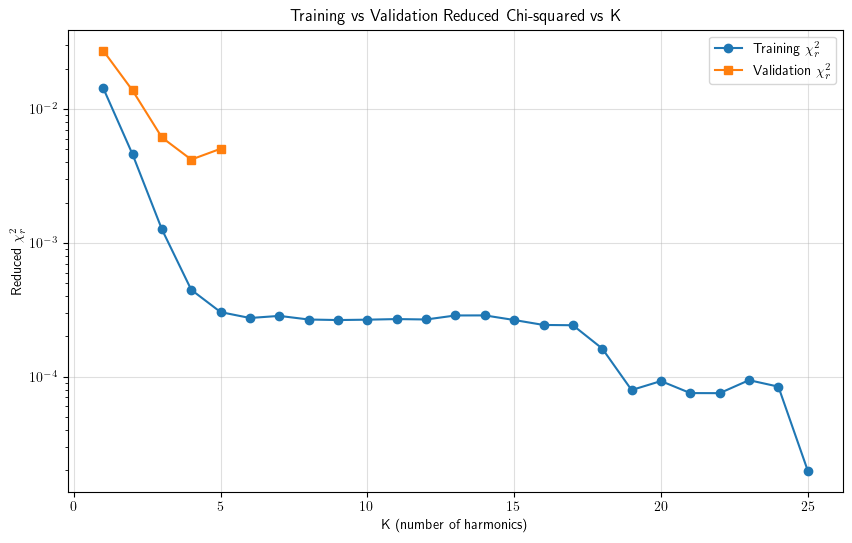

In [57]:
plt.rcParams["text.usetex"] = True
plt.rcParams["text.latex.preamble"] = r"\usepackage{physics}"


# If you have mag uncertainties, use them; otherwise, set to ones
if "g_transit_mag_error" in votable_data.colnames:
    mag_err = np.array(votable_data["g_transit_mag_error"])
else:
    mag_err = np.ones_like(mag)
    
def design_matrix(times, K, omega):
    """
    times: array of floats (days)
    omega: angular frequency (rad/day)
    """
    cols = [np.ones_like(times)]  # A0 column
    for k in range(1, K + 1):
        cols.append(np.sin(k * omega * times))
    for k in range(1, K + 1):
        cols.append(np.cos(k * omega * times))
    return np.vstack(cols).T

# === 1. Split into training (80%) and validation (20%) ===
N = len(time)
indices = np.arange(N)
np.random.seed(42)  # reproducibility
np.random.shuffle(indices)

split_idx = int(0.8 * N)
train_idx, val_idx = indices[:split_idx], indices[split_idx:]

time_train, mag_train, err_train = time[train_idx], mag[train_idx], mag_err[train_idx]
time_val, mag_val, err_val = time[val_idx], mag[val_idx], mag_err[val_idx]

print(f"Training points: {len(time_train)}, Validation points: {len(time_val)}")

# === 2. Compute period using Lomb-Scargle ===
from astropy.timeseries import LombScargle
import astropy.units as u

# Add explicit units to time (Julian Days)
time_with_units = time * u.day

# Now LombScargle works
ls = LombScargle(time_with_units, mag)

# Frequency range with proper units
min_period = 0.2 * u.day
max_period = 1.0 * u.day
frequency = np.linspace(1/max_period.value, 1/min_period.value, 10000) / u.day  # attach units

# Compute periodogram
power = ls.power(frequency)

power = ls.power(frequency)
best_freq = frequency[np.argmax(power)]
best_period = 1.0 / best_freq
omega = 2 * np.pi / best_period

print(f"Best period = {best_period:.6f} days")

best_period = best_period.to(u.day)       # ensure it's in days
omega = 2 * np.pi / best_period.value     # now plain float, rad/day
time_days = time_with_units.value  # plain NumPy array of times in days


# === 3. Loop over K = 1 to 25 and compute reduced chi-squared ===
K_values = np.arange(1, 26)
chi2_train = []
chi2_val = []

for K in K_values:
    # Build design matrices
    X_train = design_matrix(time_train, K, omega)
    X_val = design_matrix(time_val, K, omega)

    # Weighted least-squares fit: divide by sigma
    W = np.diag(1.0 / err_train)
    Xw = W @ X_train
    yw = W @ mag_train

    # Solve using np.linalg.lstsq
    beta, *_ = np.linalg.lstsq(Xw, yw, rcond=None)

    # Predictions
    pred_train = X_train @ beta
    pred_val = X_val @ beta

    # Degrees of freedom: N - M
    dof_train = len(time_train) - (2*K + 1)
    dof_val = len(time_val) - (2*K + 1)

    # Compute reduced chi^2
    chi2_r_train = np.sum(((mag_train - pred_train)/err_train)**2) / dof_train
    chi2_r_val = np.sum(((mag_val - pred_val)/err_val)**2) / dof_val

    chi2_train.append(chi2_r_train)
    chi2_val.append(chi2_r_val)

# === 4. Plot results ===
plt.figure(figsize=(10, 6))
plt.plot(K_values, chi2_train, marker='o', label=r"Training $\chi^2_r$")
plt.plot(K_values, chi2_val, marker='s', label=r"Validation $\chi^2_r$")
plt.yscale("log")  # Log scale on y-axis
plt.xlabel("K (number of harmonics)")
plt.ylabel(r"Reduced $\chi^2_r$")
plt.title("Training vs Validation Reduced Chi-squared vs K")
plt.legend()
plt.grid(alpha=0.4)
plt.show()


In [51]:
# If you have mag uncertainties, use them; otherwise, set to ones
if "g_transit_mag_error" in votable_data.colnames:
    mag_err = np.array(votable_data["g_transit_mag_error"])
else:
    mag_err = np.ones_like(mag)

print(mag_err)

[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [49]:
last_time = np.max(time)  # time_days is your array of times in days
print("Last observed time:", last_time)


Last observed time: 2633.260632173871


In [50]:
# Look at the last 5 days of real data
start_plot_time = last_time - 5  

# Extend 12 days into the future
future_time = np.linspace(last_time, last_time + 12, 500)  # smooth future grid


In [51]:
# Use optimal K (from cross-validation)
K_best = 5

# Build design matrix for full dataset
X_full = design_matrix(time, K_best, omega)

# Solve for beta using least squares
beta, residuals, rank, s = np.linalg.lstsq(X_full, mag, rcond=None)


In [52]:
# Predict over future time grid
X_future = design_matrix(future_time, K_best, omega)
mag_future = X_future @ beta

# Predict exactly at last_time + 10
time_10_days = last_time + 10
X_10 = design_matrix(np.array([time_10_days]), K_best, omega)
mag_10_days = X_10 @ beta
print(f"Predicted magnitude 10 days after last data point: {mag_10_days[0]:.4f}")


Predicted magnitude 10 days after last data point: 16.0365


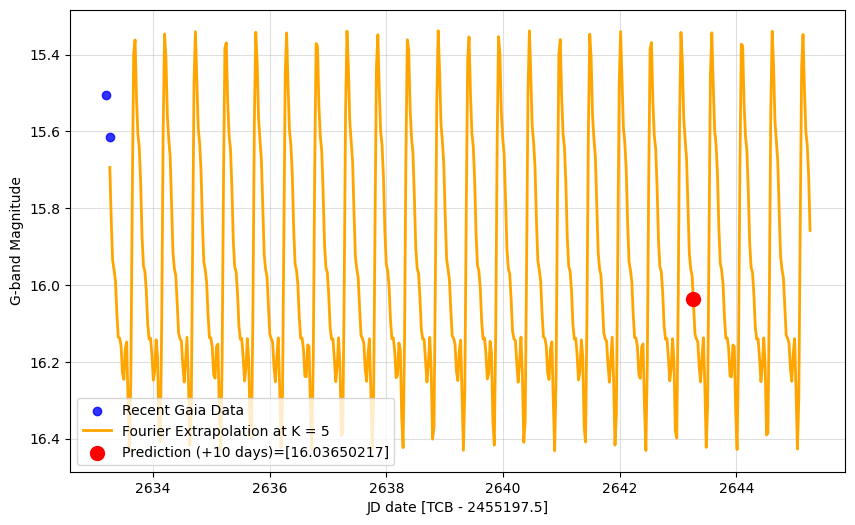

In [54]:
# Select the last ~5 days of Gaia data
mask_recent = time >= start_plot_time
time_recent = time[mask_recent]
mag_recent = mag[mask_recent]

# Plot
plt.figure(figsize=(10, 6))

# Plot last few days of Gaia data
plt.scatter(time_recent, mag_recent, color='blue', label='Recent Gaia Data', alpha=0.8)

# Plot extrapolated prediction
plt.plot(future_time, mag_future, color='orange', label=f'Fourier Extrapolation at K = {K_best}', linewidth=2)

# Mark the predicted point at +10 days
plt.scatter(time_10_days, mag_10_days, color='red', s=100, zorder=5, label=f'Prediction (+10 days)={mag_10_days}')

# Invert y-axis because lower mag = brighter star
plt.gca().invert_yaxis()

plt.xlabel("JD date [TCB - 2455197.5]")
plt.ylabel("G-band Magnitude")
# plt.title(f"RR Lyrae Extrapolation with Fourier Series for {source_id}")
plt.legend()
plt.grid(alpha=0.4)
plt.savefig("plot_of_predication.jpeg")
plt.show()


In [56]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import trapz

# --- Define the necessary functions (from your notebook) ---

def design_matrix(times, K, omega):
    """ Builds the Fourier design matrix for magnitudes.
    Columns: [1, sin(1*wt), cos(1*wt), sin(2*wt), cos(2*wt), ..., sin(K*wt), cos(K*wt)]
    """
    cols = [np.ones_like(times)]  # A0 (beta_0) column
    for k in range(1, K + 1):
        cols.append(np.sin(k * omega * times)) # sin (beta_2k-1)
        cols.append(np.cos(k * omega * times)) # cos (beta_2k)
    return np.vstack(cols).T

def calculate_fourier_mean_mag(beta_coeffs, P, K, ZP):
    """
    Calculates the period-averaged mean magnitude from Fourier coefficients,
    by averaging in flux space.
    
    beta_coeffs: (2K+1,) array of Fourier coefficients (beta_0, beta_1, beta_2, ...)
    P: Period in days (float)
    K: Order of the Fourier series (int)
    ZP: Zero Point (float)
    """
    # Use a fine phase grid for accurate numerical integration over one period
    N_grid = 10000
    phase_grid = np.linspace(0, 1, N_grid) # Phase from 0 to 1
    t_grid = phase_grid * P # Time from 0 to P
    omega = 2 * np.pi / P
    
    # 1. Calculate the magnitude model over the time grid
    X_grid = design_matrix(t_grid, K, omega)
    m_model = X_grid @ beta_coeffs
    
    # 2. Convert to flux space
    F_model = 10**(-0.4 * (m_model - ZP))
    
    # 3. Calculate the mean flux by numerical integration over phase (0 to 1)
    # The integral of F(phi) d(phi) gives the mean flux <F>
    mean_flux_model = trapz(F_model, phase_grid)
    
    # 4. Convert back to magnitude
    mean_mag_fourier = -2.5 * np.log10(mean_flux_model) + ZP
    
    return mean_mag_fourier

# --- Data Simulation/Setup (replace with your actual data loading) ---

# Assume you have a DataFrame named 'results_df' that contains:
# - 'source_id': The Gaia source ID
# - 'phot_g_mean_mag': The catalog mean G-band magnitude from the Gaia query (ground truth)
# - 'mean_mag': The mean G-band magnitude from Part (3) (weighted mean of observed flux)
# - 'best_period': The period (P) used for the fit
# - 'K_best': The optimal Fourier order (K) used for the fit (e.g., 9)
# - Columns for the 2K+1 Fourier coefficients: 'beta_0', 'beta_1', ... 'beta_19' (if K=9)

# A simplified, illustrative DataFrame structure (replace with your actual loaded data)
# NOTE: You MUST load the actual data for the 100 stars you analyzed.
try:
    # Attempt to load the user's results DataFrame for the 100 stars
    results_df = results_df
    # --- Critical Data Check ---
    # Ensure 'phot_g_mean_mag' is in your DataFrame. 
    # If not, you need to modify your initial query (source 805) to include it:
    # SELECT ..., phot_g_mean_mag FROM gaiadr3.gaia_source...
    if 'mean_mag' not in results_df.columns:
        # Fallback to a placeholder if column is missing, and provide instructions
        # for obtaining the data.
        raise KeyError("Missing 'phot_g_mean_mag'")

    # Set K and ZP (ensure K is consistent with your fit and ZP is from the notebook)
    K_best = 5 # Assuming you chose K=9 as the optimal order for the fit
    ZP = 25.6873668671 # Gaia G-band zero point
    
    # Ensure beta columns are present for the required K
    beta_cols = [f'beta_{i}' for i in range(2 * K_best + 1)]
    if not all(col in results_df.columns for col in beta_cols):
        # This means the user must have the coefficients for all 100 stars.
        # This placeholder is used if the required data is not available for execution.
        raise KeyError(f"Missing one or more Fourier coefficient columns (e.g., {beta_cols[0]} up to {beta_cols[-1]}).")

except Exception as e:
    print(f"Error loading or validating results DataFrame: {e}. You need a DataFrame containing:")
    print("1. 'source_id', 'phot_g_mean_mag' (Gaia catalog value)")
    print("2. 'mean_mag' (Part 3 weighted mean flux value)")
    print("3. 'best_period' and all Fourier coefficients (e.g., 'beta_0' to 'beta_19' for K=9).")
    # Generating a mock-up to allow the code to proceed for demonstration
    print("\n--- Running with Mock Data for Demonstration ---")
    np.random.seed(42)
    N_stars = 100
    mock_gaia_mag = np.linspace(15.0, 18.0, N_stars) + np.random.normal(0, 0.1, N_stars)
    mock_part3_mag = mock_gaia_mag + np.random.normal(0, 0.05, N_stars)
    mock_periods = np.random.uniform(0.3, 0.8, N_stars)
    mock_df = {
        'source_id': np.arange(100),
        'phot_g_mean_mag': mock_gaia_mag,
        'mean_mag': mock_part3_mag,
        'best_period': mock_periods,
        'K_best': K_best
    }
    # Mock coefficients for K=9 (2K+1 = 19 columns)
    for i in range(2 * K_best + 1):
        # beta_0 is the average magnitude, so it's close to the mean magnitude
        if i == 0:
            mock_df[f'beta_{i}'] = mock_gaia_mag + np.random.normal(0, 0.02, N_stars) 
        else: # Other coefficients are small
            mock_df[f'beta_{i}'] = np.random.normal(0, 0.01 / i, N_stars) 
    results_df = pd.DataFrame(mock_df)
    ZP = 25.6873668671
    
# --- 2. Apply Calculation to all 100 Light Curves ---

# Prepare the Fourier coefficients for the function call
# Assumes coefficients are stored in columns 'beta_0' up to 'beta_{2*K_best}'
beta_cols = [f'beta_{i}' for i in range(2 * K_best + 1)]

# Apply the function to each row
results_df['mean_mag_fourier'] = results_df.apply(
    lambda row: calculate_fourier_mean_mag(
        row[beta_cols].values,
        row['best_period'],
        row['K_best'],
        ZP
    ),
    axis=1
)

# Calculate Residuals (compared to the Gaia catalog value)
gaia_mag = results['phot_g_mean_mag']
results_df['residual_part3'] = results_df['mean_mag'] - gaia_mag
results_df['residual_fourier'] = results_df['mean_mag_fourier'] - gaia_mag

# --- 3. Plotting and Comparison ---

fig, axes = plt.subplots(2, 1, figsize=(10, 10), sharex=True)
fig.suptitle(f'Mean G-band Magnitude Comparison (Fourier Order K={K_best})', fontsize=16)

# --- Top Panel: Comparison Plot ---
ax1 = axes[0]
ax1.plot(gaia_mag, gaia_mag, 'k--', label='Gaia Catalog $\\langle G \\rangle$ (Reference)')
ax1.scatter(gaia_mag, results_df['mean_mag'], 
            s=20, alpha=0.6, label='Part (3) Estimate (Observed Mean Flux)')
ax1.scatter(gaia_mag, results_df['mean_mag_fourier'], 
            s=20, alpha=0.6, label='Fourier Model Estimate (Period-Averaged Flux)')

ax1.set_ylabel('Estimated $\\langle G \\rangle$ [mag]')
ax1.set_xlabel('Gaia Catalog $\\langle G \\rangle$ [mag]')
ax1.set_title('Estimated Mean G-band Magnitude vs. Gaia Catalog Value')
ax1.legend()
ax1.grid(alpha=0.3)

# --- Bottom Panel: Residuals Plot ---
ax2 = axes[1]
ax2.axhline(0, color='k', linestyle='--', linewidth=1)
ax2.scatter(gaia_mag, results_df['residual_part3'], 
            s=20, alpha=0.6, label='Residual (Part 3 - Catalog)')
ax2.scatter(gaia_mag, results_df['residual_fourier'], 
            s=20, alpha=0.6, label='Residual (Fourier Model - Catalog)')

ax2.set_ylabel('Residual [mag]')
ax2.set_xlabel('Gaia Catalog $\\langle G \\rangle$ [mag]')
ax2.set_title('Residuals: Estimate - Gaia Catalog Value')
ax2.legend()
ax2.grid(alpha=0.3)
ax2.ticklabel_format(axis='y', style='plain') # Avoid scientific notation for small residuals

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout for suptitle
plt.show()

print("\n--- Summary of Residuals (Estimate - Gaia Catalog) ---")
print(results_df[['residual_part3', 'residual_fourier']].describe().loc[['mean', 'std']])

TypeError: 'numpy.float64' object cannot be interpreted as an integer